# ZEBRA-SCANNER


In [1]:

from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
# import os
# import zipfile

# BASE_DIR = "/content/drive/MyDrive/ZEBRA_SCAN"

# TRAIN_ZIP = f"{BASE_DIR}/train_images.zip"
# TEST_ZIP  = f"{BASE_DIR}/test_images.zip"

# TRAIN_DIR = f"{BASE_DIR}/train_images"
# TEST_DIR  = f"{BASE_DIR}/test_images"

# # Extract train images
# if not os.path.exists(TRAIN_DIR):
#     print("Extracting train images...")
#     with zipfile.ZipFile(TRAIN_ZIP, "r") as z:
#         z.extractall(TRAIN_DIR)
# else:
#     print("Train images already extracted.")

# # Extract test images
# if not os.path.exists(TEST_DIR):
#     print("Extracting test images...")
#     with zipfile.ZipFile(TEST_ZIP, "r") as z:
#         z.extractall(TEST_DIR)
# else:
#     print("Test images already extracted.")

# print("\nExtraction complete.")

In [3]:
import os

BASE_DIR = "/content/drive/MyDrive/ZEBRA_SCAN"

TRAIN_JSON = f"{BASE_DIR}/zebrafish_train.json"
TEST_JSON  = f"{BASE_DIR}/zebrafish_test.json"

TRAIN_IMG_DIR = f"{BASE_DIR}/train_images/train_images"
TEST_IMG_DIR  = f"{BASE_DIR}/test_images/test_images"

OUTPUT_DIR = f"{BASE_DIR}/outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Train JSON     :", TRAIN_JSON)
print("Test JSON      :", TEST_JSON)
print("Train images   :", TRAIN_IMG_DIR)
print("Test images    :", TEST_IMG_DIR)
print("Output         :", OUTPUT_DIR)

Train JSON     : /content/drive/MyDrive/ZEBRA_SCAN/zebrafish_train.json
Test JSON      : /content/drive/MyDrive/ZEBRA_SCAN/zebrafish_test.json
Train images   : /content/drive/MyDrive/ZEBRA_SCAN/train_images/train_images
Test images    : /content/drive/MyDrive/ZEBRA_SCAN/test_images/test_images
Output         : /content/drive/MyDrive/ZEBRA_SCAN/outputs


In [4]:
import os
import json


# Load JSON
with open(TRAIN_JSON, "r") as f:
    train_coco = json.load(f)

with open(TEST_JSON, "r") as f:
    test_coco = json.load(f)

# Basic counts
train_json_names = {x["file_name"] for x in train_coco["images"]}
test_json_names = {x["file_name"] for x in test_coco["images"]}

train_disk_names = set(os.listdir(TRAIN_IMG_DIR))
test_disk_names = set(os.listdir(TEST_IMG_DIR))

print("========== DATA INTEGRITY CHECK ==========")

print("Train JSON images :", len(train_json_names))
print("Train disk images :", len(train_disk_names))
print("Test JSON images  :", len(test_json_names))
print("Test disk images  :", len(test_disk_names))

print("\nTrain JSON ↔ disk match:",
      train_json_names == train_disk_names)

print("Test JSON ↔ disk match :",
      test_json_names == test_disk_names)

print("\nTrain/Test filename overlap:",
      len(train_json_names & test_json_names))

print("\nTrain annotations:", len(train_coco["annotations"]))
print("Test annotations :", len(test_coco["annotations"]))

print("\nCategories:")
for c in train_coco["categories"]:
    print(c["id"], "→", c["name"])

print("\n==========================================")

========== DATA INTEGRITY CHECK ==========
Train JSON images : 1062
Train disk images : 1062
Test JSON images  : 266
Test disk images  : 266

Train JSON ↔ disk match: True
Test JSON ↔ disk match : True

Train/Test filename overlap: 0

Train annotations: 6731
Test annotations : 1686

Categories:
1 → eye
2 → yolk
3 → heart
4 → head
5 → bent_spine
6 → jaw_malformation
7 → tail
8 → swim_bladder_absence
9 → lower_jaw
10 → spine
11 → swim_bladder
12 → yolk_edema
13 → pericardial_edema
14 → dead
15 → head_hemorrhage
16 → unhatched_embryo



In [5]:
# ============================================================
# 0. SETUP
# ============================================================

import os
import json
import math
import time
import zipfile
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

SEED = 42

ANATOMY_CLASSES = [
    "eye", "yolk", "heart", "head",
    "tail", "lower_jaw", "spine", "swim_bladder"
]

PHENOTYPES = [
    "bent_spine",
    "jaw_malformation",
    "swim_bladder_absence",
    "yolk_edema",
    "pericardial_edema",
    "dead",
    "head_hemorrhage",
    "unhatched_embryo"
]


print("Setup complete.")


Setup complete.


In [6]:

# CHECK DATASET FILES

required = {
    "train JSON": TRAIN_JSON,
    "test JSON": TEST_JSON,
    "train images": TRAIN_IMG_DIR,
    "test images": TEST_IMG_DIR,
}

for name, path in required.items():
    print(f"{name:15s}:", "FOUND" if os.path.exists(path) else "MISSING", path)

missing = [name for name, path in required.items() if not os.path.exists(path)]

if missing:
    print("\nMissing:", missing)

else:
    print("\ndataset items are present.")


train JSON     : FOUND /content/drive/MyDrive/ZEBRA_SCAN/zebrafish_train.json
test JSON      : FOUND /content/drive/MyDrive/ZEBRA_SCAN/zebrafish_test.json
train images   : FOUND /content/drive/MyDrive/ZEBRA_SCAN/train_images/train_images
test images    : FOUND /content/drive/MyDrive/ZEBRA_SCAN/test_images/test_images

dataset items are present.


In [7]:

# LOAD COCO JSON


with open(TRAIN_JSON, "r", encoding="utf-8") as f:
    train_coco = json.load(f)

with open(TEST_JSON, "r", encoding="utf-8") as f:
    test_coco = json.load(f)

category_map = {
    c["id"]: c["name"]
    for c in train_coco["categories"]
}

all_annotations = (
    train_coco["annotations"] +
    test_coco["annotations"]
)

print("Train images:", len(train_coco["images"]))
print("Train annotations:", len(train_coco["annotations"]))
print("Test images:", len(test_coco["images"]))
print("Test annotations:", len(test_coco["annotations"]))
print("Categories:", len(category_map))
print("Total images:", len(train_coco["images"]) + len(test_coco["images"]))


Train images: 1062
Train annotations: 6731
Test images: 266
Test annotations: 1686
Categories: 16
Total images: 1328


In [8]:

#  BUILD MASTER IMAGE TABLE + IMAGE-LEVEL LABELS

records = []

for img in train_coco["images"]:
    records.append({
        "image_id": img["id"],
        "filename": img["file_name"],
        "width": img["width"],
        "height": img["height"],
        "source_split": "author_train"
    })

for img in test_coco["images"]:
    records.append({
        "image_id": img["id"],
        "filename": img["file_name"],
        "width": img["width"],
        "height": img["height"],
        "source_split": "author_test"
    })

df_images = pd.DataFrame(records)

image_categories = defaultdict(set)

for ann in all_annotations:
    image_categories[ann["image_id"]].add(
        category_map[ann["category_id"]]
    )

for phenotype in PHENOTYPES:
    df_images[phenotype] = df_images["image_id"].map(
        lambda x, p=phenotype:
        int(p in image_categories.get(x, set()))
    )

print("Master shape:", df_images.shape)
print("\nSource split:")
print(df_images["source_split"].value_counts())

print("\nPhenotype counts:")
print(df_images[PHENOTYPES].sum().sort_values(ascending=False))


Master shape: (1328, 13)

Source split:
source_split
author_train    1062
author_test      266
Name: count, dtype: int64

Phenotype counts:
swim_bladder_absence    786
jaw_malformation        680
pericardial_edema       554
yolk_edema              348
bent_spine              323
unhatched_embryo        237
head_hemorrhage         207
dead                     69
dtype: int64


In [9]:

#  BASIC DATASET INTEGRITY

train_ids = {x["id"] for x in train_coco["images"]}
test_ids = {x["id"] for x in test_coco["images"]}

train_files = {x["file_name"] for x in train_coco["images"]}
test_files = {x["file_name"] for x in test_coco["images"]}

print("Image-ID overlap:", len(train_ids & test_ids))
print("Filename overlap:", len(train_files & test_files))

assert len(train_ids & test_ids) == 0
assert len(train_files & test_files) == 0

print("Dataset overlap audit: PASSED")


Image-ID overlap: 0
Filename overlap: 0
Dataset overlap audit: PASSED


In [10]:

#  IMAGE FILE COUNT AUDIT

def list_images(folder):
    extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    paths = []

    for root, _, filenames in os.walk(folder):
        for filename in filenames:
            if os.path.splitext(filename)[1].lower() in extensions:
                paths.append(os.path.join(root, filename))

    return sorted(paths)

train_files_on_disk = list_images(TRAIN_IMG_DIR)
test_files_on_disk = list_images(TEST_IMG_DIR)

print("Train image files:", len(train_files_on_disk))
print("Test image files :", len(test_files_on_disk))
print("Total:", len(train_files_on_disk) + len(test_files_on_disk))

assert len(train_files_on_disk) == len(train_coco["images"])
assert len(test_files_on_disk) == len(test_coco["images"])

print("Image-file audit: PASSED")


Train image files: 1062
Test image files : 266
Total: 1328
Image-file audit: PASSED


## 6. Freeze the experimental split

The author-provided train/test split is preserved as metadata, but the actual experiment uses our own **80/20 multilabel-stratified split**.

The 20% test set is locked and is not used for morphology construction decisions or model selection.


In [11]:

#  EXPERIMENTAL 80/20 MULTILABEL-STRATIFIED SPLIT


!pip -q install iterative-stratification

from iterstrat.ml_stratifiers import (
    MultilabelStratifiedShuffleSplit,
    MultilabelStratifiedKFold
)

splitter = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED
)

Y_all = df_images[PHENOTYPES].values
dummy_X = np.zeros(len(df_images))

dev_idx, test_idx = next(
    splitter.split(dummy_X, Y_all)
)

df_master = df_images.copy()
df_master["experimental_split"] = "dev"
df_master.loc[test_idx, "experimental_split"] = "test"

print(df_master["experimental_split"].value_counts())


experimental_split
dev     1062
test     266
Name: count, dtype: int64


In [12]:

#  SPLIT PREVALENCE CHECK


overall = df_master[PHENOTYPES].mean() * 100
dev = (
    df_master.loc[df_master["experimental_split"] == "dev", PHENOTYPES]
    .mean() * 100
)
test = (
    df_master.loc[df_master["experimental_split"] == "test", PHENOTYPES]
    .mean() * 100
)

split_check = pd.DataFrame({
    "overall_%": overall,
    "dev_%": dev,
    "test_%": test,
    "dev_diff": dev - overall,
    "test_diff": test - overall
})

display(split_check.round(2))


,overall_%,dev_%,test_%,dev_diff,test_diff
bent_spine,24.32,24.29,24.44,-0.03,0.11
jaw_malformation,51.20,51.22,51.13,0.02,-0.08
swim_bladder_absence,59.19,59.23,59.02,0.04,-0.16
yolk_edema,26.20,26.18,26.32,-0.03,0.11
pericardial_edema,41.72,41.71,41.73,-0.00,0.01
dead,5.20,5.18,5.26,-0.02,0.07
head_hemorrhage,15.59,15.63,15.41,0.04,-0.17
unhatched_embryo,17.85,17.89,17.67,0.04,-0.18


In [13]:

#  FREEZE DEVELOPMENT / LOCKED TEST


df_dev = (
    df_master[df_master["experimental_split"] == "dev"]
    .copy()
    .reset_index(drop=True)
)

df_test = (
    df_master[df_master["experimental_split"] == "test"]
    .copy()
    .reset_index(drop=True)
)

print("Development:", df_dev.shape)
print("Locked test :", df_test.shape)

assert set(df_dev.image_id).isdisjoint(set(df_test.image_id))

print("Locked-test separation: PASSED")


Development: (1062, 14)
Locked test : (266, 14)
Locked-test separation: PASSED


In [14]:

#  5-FOLD MULTILABEL-STRATIFIED CV


Y_dev = df_dev[PHENOTYPES].values

mskf = MultilabelStratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

folds = []

for fold_id, (train_idx, val_idx) in enumerate(
    mskf.split(np.zeros(len(df_dev)), Y_dev)
):
    folds.append((train_idx, val_idx))

print("Number of folds:", len(folds))

for i, (train_idx, val_idx) in enumerate(folds):
    print(
        f"Fold {i}: train={len(train_idx)}, "
        f"validation={len(val_idx)}"
    )

all_val_indices = np.concatenate([v for _, v in folds])

assert len(all_val_indices) == len(df_dev)
assert len(np.unique(all_val_indices)) == len(df_dev)

for train_idx, val_idx in folds:
    assert len(set(train_idx) & set(val_idx)) == 0

print("\n5-FOLD CV INTEGRITY: PASSED")


Number of folds: 5
Fold 0: train=849, validation=213
Fold 1: train=850, validation=212
Fold 2: train=849, validation=213
Fold 3: train=850, validation=212
Fold 4: train=850, validation=212

5-FOLD CV INTEGRITY: PASSED


In [15]:

#  ANATOMICAL ANNOTATION AUDIT


anatomy_annotations = [
    ann for ann in all_annotations
    if category_map[ann["category_id"]] in ANATOMY_CLASSES
]

anatomy_by_image = defaultdict(list)

for ann in anatomy_annotations:
    anatomy_by_image[ann["image_id"]].append(ann)

audit_rows = []

for _, row in df_images.iterrows():
    labels = image_categories.get(row["image_id"], set())

    anatomy_present = [
        c for c in ANATOMY_CLASSES if c in labels
    ]

    audit_rows.append({
        "image_id": row["image_id"],
        "n_anatomy": len(anatomy_present),
        "anatomy_present": ", ".join(anatomy_present),
        "phenotypes": ", ".join(
            p for p in PHENOTYPES if p in labels
        )
    })

df_audit = pd.DataFrame(audit_rows)

print("Total anatomical annotations:", len(anatomy_annotations))
print("Images with zero anatomical annotations:",
      (df_audit["n_anatomy"] == 0).sum())

print("\nAnatomical labels per image:")
print(df_audit["n_anatomy"].value_counts().sort_index())


Total anatomical annotations: 5211
Images with zero anatomical annotations: 306

Anatomical labels per image:
n_anatomy
0    306
1      1
2     13
3    170
4    254
5    257
6    100
7     45
8    182
Name: count, dtype: int64


In [16]:

#  MORPHOMETRIC FEATURE EXTRACTION


def extract_morphology(image_id, width, height):
    anns = anatomy_by_image.get(image_id, [])
    features = {}

    for anatomy in ANATOMY_CLASSES:
        features[f"{anatomy}_area"] = 0.0
        features[f"{anatomy}_area_frac"] = 0.0
        features[f"{anatomy}_bbox_w"] = 0.0
        features[f"{anatomy}_bbox_h"] = 0.0
        features[f"{anatomy}_aspect"] = 0.0
        features[f"{anatomy}_cx"] = 0.0
        features[f"{anatomy}_cy"] = 0.0
        features[f"{anatomy}_bbox_w_norm"] = 0.0
        features[f"{anatomy}_bbox_h_norm"] = 0.0
        features[f"{anatomy}_available"] = 0

    for ann in anns:
        anatomy = category_map[ann["category_id"]]

        if anatomy not in ANATOMY_CLASSES:
            continue

        x, y, w, h = ann["bbox"]
        area = float(ann["area"])

        features[f"{anatomy}_area"] = area
        features[f"{anatomy}_area_frac"] = area / (width * height)
        features[f"{anatomy}_bbox_w"] = w
        features[f"{anatomy}_bbox_h"] = h
        features[f"{anatomy}_aspect"] = w / h if h > 0 else 0
        features[f"{anatomy}_cx"] = (x + w / 2) / width
        features[f"{anatomy}_cy"] = (y + h / 2) / height
        features[f"{anatomy}_bbox_w_norm"] = w / width
        features[f"{anatomy}_bbox_h_norm"] = h / height
        features[f"{anatomy}_available"] = 1

    return features


morph_rows = []

for _, row in df_dev.iterrows():
    features = extract_morphology(
        row["image_id"],
        row["width"],
        row["height"]
    )
    features["image_id"] = row["image_id"]
    morph_rows.append(features)

df_morph = pd.DataFrame(morph_rows)

print("Basic morphology:", df_morph.shape)


Basic morphology: (1062, 81)


In [17]:

#  SHAPE FEATURES


from scipy.spatial import ConvexHull

def polygon_points_from_annotation(ann):
    segmentation = ann.get("segmentation", [])

    if not segmentation:
        return None

    points = []

    for poly in segmentation:
        if len(poly) >= 6:
            points.append(
                np.asarray(poly, dtype=float).reshape(-1, 2)
            )

    if not points:
        return None

    return np.vstack(points)


def polygon_perimeter(points):
    if points is None or len(points) < 3:
        return np.nan

    closed = np.vstack([points, points[0]])
    return float(
        np.linalg.norm(np.diff(closed, axis=0), axis=1).sum()
    )


def polygon_circularity(area, perimeter):
    if not np.isfinite(perimeter) or perimeter <= 0:
        return np.nan

    return float(4 * np.pi * area / (perimeter ** 2))


def polygon_solidity(points, area):
    if points is None or len(points) < 3:
        return np.nan

    try:
        hull = ConvexHull(points)
        hull_area = hull.volume
        return float(area / hull_area) if hull_area > 0 else np.nan
    except Exception:
        return np.nan


shape_rows = []

for _, row in df_dev.iterrows():
    image_id = row["image_id"]
    feature_row = {"image_id": image_id}

    for ann in anatomy_by_image.get(image_id, []):
        anatomy = category_map[ann["category_id"]]

        if anatomy not in ANATOMY_CLASSES:
            continue

        area = float(ann["area"])
        points = polygon_points_from_annotation(ann)
        perimeter = polygon_perimeter(points)

        feature_row[f"{anatomy}_perimeter"] = perimeter
        feature_row[f"{anatomy}_circularity"] = polygon_circularity(
            area, perimeter
        )
        feature_row[f"{anatomy}_solidity"] = polygon_solidity(
            points, area
        )

    shape_rows.append(feature_row)

df_shape = pd.DataFrame(shape_rows)

print("Shape features:", df_shape.shape)


Shape features: (1062, 25)


In [18]:

#  RELATIVE ANATOMICAL GEOMETRY


RELATION_PAIRS = [
    ("eye", "head"),
    ("eye", "tail"),
    ("head", "tail"),
    ("head", "spine"),
    ("tail", "spine"),
    ("yolk", "head"),
    ("heart", "head"),
    ("lower_jaw", "head"),
    ("swim_bladder", "head")
]

def get_annotation_by_class(image_id):
    result = {}

    for ann in anatomy_by_image.get(image_id, []):
        anatomy = category_map[ann["category_id"]]

        if anatomy in ANATOMY_CLASSES:
            result[anatomy] = ann

    return result


def centroid_from_annotation(ann):
    x, y, w, h = ann["bbox"]
    return np.array([x + w / 2, y + h / 2])


relative_rows = []

for _, row in df_dev.iterrows():
    image_id = row["image_id"]
    anns = get_annotation_by_class(image_id)
    diagonal = np.hypot(row["width"], row["height"])

    feature_row = {"image_id": image_id}

    for a, b in RELATION_PAIRS:
        col = f"{a}_{b}_distance"

        if a in anns and b in anns:
            distance = np.linalg.norm(
                centroid_from_annotation(anns[a]) -
                centroid_from_annotation(anns[b])
            )
            feature_row[col] = distance / diagonal
        else:
            feature_row[col] = np.nan

    relative_rows.append(feature_row)

df_relative = pd.DataFrame(relative_rows)

print("Relative geometry:", df_relative.shape)


Relative geometry: (1062, 10)


## 14. Spine-specific features

The spine feature is a **tortuosity proxy**, not a gold-standard anatomical curvature measurement:

\[
\text{tortuosity proxy}
=
\frac{\text{skeleton path length}}
{\text{head-tail centroid distance}}
\]

It is extracted from the annotated spine segmentation.


In [19]:

# SPINE FEATURES


!pip -q install scikit-image

from skimage.draw import polygon
from skimage.morphology import skeletonize


def annotation_to_mask(ann, width, height):
    mask = np.zeros((int(height), int(width)), dtype=bool)

    for poly in ann.get("segmentation", []):
        if len(poly) < 6:
            continue

        coords = np.asarray(poly, dtype=float).reshape(-1, 2)

        rr, cc = polygon(
            coords[:, 1],
            coords[:, 0],
            shape=mask.shape
        )

        mask[rr, cc] = True

    return mask


def skeleton_path_length(skeleton):
    coords = np.argwhere(skeleton)

    if len(coords) < 2:
        return np.nan

    coord_set = {tuple(c) for c in coords}
    length = 0.0

    for r, c in coord_set:
        for dr, dc in [(0, 1), (1, 0), (1, 1), (1, -1)]:
            if (r + dr, c + dc) in coord_set:
                length += np.hypot(dr, dc)

    return float(length)


def calculate_spine_curvature(
    spine_ann, width, height, head_ann=None, tail_ann=None
):
    mask = annotation_to_mask(spine_ann, width, height)
    skeleton = skeletonize(mask)
    spine_length = skeleton_path_length(skeleton)

    result = {
        "spine_centerline_length": spine_length,
        "spine_curvature_ratio": np.nan,
        "spine_straightness": np.nan
    }

    if head_ann is None or tail_ann is None:
        return result

    if not np.isfinite(spine_length):
        return result

    head_c = centroid_from_annotation(head_ann)
    tail_c = centroid_from_annotation(tail_ann)

    head_tail_distance = np.linalg.norm(head_c - tail_c)

    if head_tail_distance <= 0 or spine_length <= 0:
        return result

    result["spine_curvature_ratio"] = (
        spine_length / head_tail_distance
    )
    result["spine_straightness"] = (
        head_tail_distance / spine_length
    )

    return result


spine_rows = []

for _, row in df_dev.iterrows():
    anns = get_annotation_by_class(row["image_id"])

    feature_row = {
        "image_id": row["image_id"],
        "spine_centerline_length": np.nan,
        "spine_curvature_ratio": np.nan,
        "spine_straightness": np.nan
    }

    if "spine" in anns:
        feature_row.update(
            calculate_spine_curvature(
                anns["spine"],
                row["width"],
                row["height"],
                anns.get("head"),
                anns.get("tail")
            )
        )

    spine_rows.append(feature_row)

df_spine = pd.DataFrame(spine_rows)

print("Spine feature table:", df_spine.shape)
print("\nValid curvature measurements:",
      df_spine["spine_curvature_ratio"].notna().sum())
print(df_spine["spine_curvature_ratio"].describe())


Spine feature table: (1062, 4)

Valid curvature measurements: 445
count    445.000000
mean       0.963189
std        0.057349
min        0.132700
25%        0.935763
50%        0.962364
75%        0.992471
max        1.089325
Name: spine_curvature_ratio, dtype: float64


In [20]:

#  BUILD FINAL MORPHOLOGY MATRIX


df_morphology = (
    df_morph
    .merge(df_shape, on="image_id", how="left", validate="one_to_one")
    .merge(df_relative, on="image_id", how="left", validate="one_to_one")
    .merge(df_spine, on="image_id", how="left", validate="one_to_one")
)

feature_cols = [
    c for c in df_morphology.columns
    if c != "image_id"
]

assert df_morphology["image_id"].duplicated().sum() == 0
assert len(df_morphology) == len(df_dev)

numeric_cols = df_morphology[feature_cols].select_dtypes(
    include=np.number
).columns

print("Final morphology shape:", df_morphology.shape)
print("Feature count:", len(feature_cols))
print("Numeric features:", len(numeric_cols))
print("Infinite values:",
      np.isinf(df_morphology[numeric_cols].to_numpy()).sum())
print("Total NaNs:",
      df_morphology[numeric_cols].isna().sum().sum())


Final morphology shape: (1062, 117)
Feature count: 116
Numeric features: 116
Infinite values: 0
Total NaNs: 20137


In [21]:

#  MODEL B DATASET


df_B = (
    df_dev[["image_id"] + PHENOTYPES]
    .merge(
        df_morphology,
        on="image_id",
        how="left",
        validate="one_to_one"
    )
)

assert len(df_B) == len(df_dev)
assert df_B["image_id"].nunique() == len(df_dev)
assert df_B[PHENOTYPES].isna().sum().sum() == 0

X_B = df_B[feature_cols].copy()
Y_B = df_B[PHENOTYPES].copy()

print("Model B dataset:", df_B.shape)
print("X:", X_B.shape)
print("Y:", Y_B.shape)


Model B dataset: (1062, 125)
X: (1062, 116)
Y: (1062, 8)


In [22]:

#  MODEL B EVALUATION FUNCTION


from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.multioutput import MultiOutputClassifier

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    average_precision_score
)


def make_morphology_model(add_missing_indicators):
    return Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=add_missing_indicators
            )
        ),
        ("scaler", StandardScaler()),
        (
            "classifier",
            MultiOutputClassifier(
                MLPClassifier(
                    hidden_layer_sizes=(128, 64),
                    activation="relu",
                    solver="adam",
                    alpha=1e-4,
                    batch_size=32,
                    learning_rate_init=1e-3,
                    max_iter=300,
                    early_stopping=True,
                    validation_fraction=0.15,
                    n_iter_no_change=15,
                    random_state=SEED
                )
            )
        )
    ])


def evaluate_morphology_cv(X, Y, add_missing_indicators=True, name="Model"):
    results = []
    all_predictions = []

    for fold_id, (train_idx, val_idx) in enumerate(folds):
        model = make_morphology_model(add_missing_indicators)

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        Y_train = Y.iloc[train_idx]
        Y_val = Y.iloc[val_idx]

        start = time.time()

        model.fit(X_train, Y_train)

        Y_pred = model.predict(X_val)
        prob_list = model.predict_proba(X_val)
        Y_prob = np.column_stack([p[:, 1] for p in prob_list])

        elapsed = time.time() - start

        per_label_f1 = f1_score(
            Y_val, Y_pred,
            average=None,
            zero_division=0
        )

        pr_auc = [
            average_precision_score(
                Y_val.iloc[:, j],
                Y_prob[:, j]
            )
            for j in range(len(PHENOTYPES))
        ]

        results.append({
            "model": name,
            "fold": fold_id,
            "macro_f1": f1_score(
                Y_val, Y_pred,
                average="macro",
                zero_division=0
            ),
            "micro_f1": f1_score(
                Y_val, Y_pred,
                average="micro",
                zero_division=0
            ),
            "macro_precision": precision_score(
                Y_val, Y_pred,
                average="macro",
                zero_division=0
            ),
            "macro_recall": recall_score(
                Y_val, Y_pred,
                average="macro",
                zero_division=0
            ),
            "macro_pr_auc": np.mean(pr_auc),
            "runtime_sec": elapsed
        })

        pred_df = pd.DataFrame(
            Y_prob,
            columns=[f"{p}_prob" for p in PHENOTYPES]
        )

        pred_df["fold"] = fold_id
        pred_df["image_index"] = val_idx

        for j, phenotype in enumerate(PHENOTYPES):
            pred_df[f"{phenotype}_true"] = Y_val.iloc[:, j].values
            pred_df[f"{phenotype}_pred"] = Y_pred[:, j]

        all_predictions.append(pred_df)

        print(
            f"{name} | Fold {fold_id} | "
            f"Macro-F1={results[-1]['macro_f1']:.4f} | "
            f"Micro-F1={results[-1]['micro_f1']:.4f} | "
            f"PR-AUC={results[-1]['macro_pr_auc']:.4f} | "
            f"{elapsed:.1f}s"
        )

    return pd.DataFrame(results), pd.concat(
        all_predictions, ignore_index=True
    )


def print_cv_summary(results):
    print("\n" + "=" * 60)
    print(results["model"].iloc[0], "SUMMARY")
    print("=" * 60)

    for metric in [
        "macro_f1",
        "micro_f1",
        "macro_precision",
        "macro_recall",
        "macro_pr_auc"
    ]:
        print(
            f"{metric:20s}: "
            f"{results[metric].mean():.4f} ± "
            f"{results[metric].std():.4f}"
        )


## 18. B1 — Full morphology

B1 uses the 116 morphology features, including explicit anatomical availability flags, and imputation-generated missingness indicators.


In [23]:

#  MODEL B1


cv_results_B1, cv_predictions_B1 = evaluate_morphology_cv(
    X_B,
    Y_B,
    add_missing_indicators=True,
    name="B1"
)

print_cv_summary(cv_results_B1)


B1 | Fold 0 | Macro-F1=0.8515 | Micro-F1=0.9709 | PR-AUC=0.8717 | 15.5s
B1 | Fold 1 | Macro-F1=0.8443 | Micro-F1=0.9616 | PR-AUC=0.8685 | 16.9s
B1 | Fold 2 | Macro-F1=0.8479 | Micro-F1=0.9658 | PR-AUC=0.8724 | 8.2s
B1 | Fold 3 | Macro-F1=0.8472 | Micro-F1=0.9632 | PR-AUC=0.8581 | 5.0s
B1 | Fold 4 | Macro-F1=0.8488 | Micro-F1=0.9658 | PR-AUC=0.8703 | 8.9s

B1 SUMMARY
macro_f1            : 0.8479 ± 0.0026
micro_f1            : 0.9654 ± 0.0035
macro_precision     : 0.8341 ± 0.0080
macro_recall        : 0.8658 ± 0.0041
macro_pr_auc        : 0.8682 ± 0.0058


## 19. B2 — Remove explicit availability flags

B2 removes the eight `*_available` variables but still lets the imputer generate missingness indicators.


In [24]:

# MODEL B2


morph_features_no_availability = [
    c for c in feature_cols
    if not c.endswith("_available")
]

X_B2 = df_B[morph_features_no_availability].copy()

print("Full features:", len(feature_cols))
print("B2 features :", len(morph_features_no_availability))

cv_results_B2, cv_predictions_B2 = evaluate_morphology_cv(
    X_B2,
    Y_B,
    add_missing_indicators=True,
    name="B2"
)

print_cv_summary(cv_results_B2)


Full features: 116
B2 features : 108
B2 | Fold 0 | Macro-F1=0.8492 | Micro-F1=0.9690 | PR-AUC=0.8729 | 15.1s
B2 | Fold 1 | Macro-F1=0.8408 | Micro-F1=0.9585 | PR-AUC=0.8649 | 19.9s
B2 | Fold 2 | Macro-F1=0.8473 | Micro-F1=0.9657 | PR-AUC=0.8702 | 5.9s
B2 | Fold 3 | Macro-F1=0.8440 | Micro-F1=0.9603 | PR-AUC=0.8596 | 6.1s
B2 | Fold 4 | Macro-F1=0.8492 | Micro-F1=0.9659 | PR-AUC=0.8703 | 4.7s

B2 SUMMARY
macro_f1            : 0.8461 ± 0.0037
micro_f1            : 0.9639 ± 0.0043
macro_precision     : 0.8330 ± 0.0066
macro_recall        : 0.8632 ± 0.0039
macro_pr_auc        : 0.8676 ± 0.0053


## 20. B3 — Conservative morphology baseline

B3 removes both:
- explicit anatomical availability flags
- imputation-generated missingness indicators

Only the numerical morphology/shape/relative-geometry measurements remain after median imputation.


In [25]:

#  MODEL B3


X_B3 = df_B[morph_features_no_availability].copy()

cv_results_B3, cv_predictions_B3 = evaluate_morphology_cv(
    X_B3,
    Y_B,
    add_missing_indicators=False,
    name="B3"
)

print_cv_summary(cv_results_B3)


B3 | Fold 0 | Macro-F1=0.8509 | Micro-F1=0.9699 | PR-AUC=0.8731 | 7.8s
B3 | Fold 1 | Macro-F1=0.8398 | Micro-F1=0.9568 | PR-AUC=0.8642 | 4.2s
B3 | Fold 2 | Macro-F1=0.8500 | Micro-F1=0.9649 | PR-AUC=0.8675 | 4.2s
B3 | Fold 3 | Macro-F1=0.8358 | Micro-F1=0.9553 | PR-AUC=0.8587 | 7.6s
B3 | Fold 4 | Macro-F1=0.8456 | Micro-F1=0.9638 | PR-AUC=0.8688 | 4.4s

B3 SUMMARY
macro_f1            : 0.8444 ± 0.0065
micro_f1            : 0.9621 ± 0.0061
macro_precision     : 0.8325 ± 0.0084
macro_recall        : 0.8606 ± 0.0093
macro_pr_auc        : 0.8665 ± 0.0054


In [26]:

# 21. B1 / B2 / B3 COMPARISON


summary = pd.concat(
    [
        cv_results_B1.groupby("model").agg(
            macro_f1=("macro_f1", "mean"),
            macro_f1_sd=("macro_f1", "std"),
            micro_f1=("micro_f1", "mean"),
            macro_pr_auc=("macro_pr_auc", "mean")
        ),
        cv_results_B2.groupby("model").agg(
            macro_f1=("macro_f1", "mean"),
            macro_f1_sd=("macro_f1", "std"),
            micro_f1=("micro_f1", "mean"),
            macro_pr_auc=("macro_pr_auc", "mean")
        ),
        cv_results_B3.groupby("model").agg(
            macro_f1=("macro_f1", "mean"),
            macro_f1_sd=("macro_f1", "std"),
            micro_f1=("micro_f1", "mean"),
            macro_pr_auc=("macro_pr_auc", "mean")
        )
    ]
)

display(summary.round(4))

print("\nB3 is the conservative morphology baseline to carry forward.")


,macro_f1,macro_f1_sd,micro_f1,macro_pr_auc
model,,,,
B1,0.8479,0.0026,0.9654,0.8682
B2,0.8461,0.0037,0.9639,0.8676
B3,0.8444,0.0065,0.9621,0.8665



B3 is the conservative morphology baseline to carry forward.


In [27]:

# 22. OPTIONAL: PER-PHENOTYPE B3 PERFORMANCE


# Reconstruct out-of-fold B3 predictions and calculate F1 per phenotype.
per_label = {}

for phenotype in PHENOTYPES:
    y_true = cv_predictions_B3[f"{phenotype}_true"]
    y_pred = cv_predictions_B3[f"{phenotype}_pred"]

    per_label[phenotype] = f1_score(
        y_true, y_pred, zero_division=0
    )

per_label_B3 = (
    pd.Series(per_label, name="B3_F1")
    .sort_values(ascending=False)
)

display(per_label_B3.to_frame().round(4))


,B3_F1
bent_spine,0.9902
swim_bladder_absence,0.9882
pericardial_edema,0.9876
yolk_edema,0.9800
jaw_malformation,0.9720
head_hemorrhage,0.9636
unhatched_embryo,0.8736
dead,0.0000


# End of B3

At this point the clean notebook has reproduced the morphology pipeline through the conservative B3 baseline.

Expected reference result from the previous run:

**B3 Macro-F1 ≈ 0.8444 ± 0.0065**

**B3 Micro-F1 ≈ 0.9621 ± 0.0061**

**B3 Macro PR-AUC ≈ 0.8669 ± 0.0057**

Small numerical differences can occur if the runtime/library versions differ, but the experimental split and seed are fixed.

### Next stage
Move to the **A0 CNN-from-scratch image model** on the T4 GPU.


In [28]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA: True
GPU: Tesla T4


In [29]:
import sys
print("Python:", sys.version)

!pip show torch torchvision

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Name: torch
Version: 2.11.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.13/dist-packages
Requires: cuda-bindings, cuda-toolkit, filelock, fsspec, jinja2, networkx, nvidia-cudnn-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvshmem-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchdata, torchvision
---
Name: torchvision
Version: 0.26.0+cu128
Summary: image and video datasets and models for torch deep learning
Home-page: https://github.com/pytorch/vision
Author: PyTorch Core Team
Author-email: soumith@pytorch.org
License: BSD
Location: /usr/local/lib/python3.13/dist-packages
Requires: numpy, pillow, torch
Required-by: fastai, timm


In [30]:
# ============================================================
# ZEBRA-SCAN — IMAGE BRANCH
# A0: SCRATCH CNN
# A1: RESNET18 TRANSFER LEARNING
# ============================================================

import os
import json
import time
import copy
import pickle
import random
import warnings

import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    average_precision_score
)

warnings.filterwarnings("ignore")

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using:", DEVICE)

PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4
Using: cuda


In [31]:

# OUTPUT DIRECTORY


CNN_DIR = os.path.join(
    OUTPUT_DIR,
    "cnn"
)

os.makedirs(
    CNN_DIR,
    exist_ok=True
)

print("CNN output directory:")
print(CNN_DIR)

CNN output directory:
/content/drive/MyDrive/ZEBRA_SCAN/outputs/cnn


In [32]:

# REPRODUCIBILITY


SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Faster training on T4
torch.backends.cudnn.benchmark = True

print("Seed:", SEED)

Seed: 42


In [33]:

# PHENOTYPE TARGETS


PHENOTYPES = [
    "bent_spine",
    "jaw_malformation",
    "swim_bladder_absence",
    "yolk_edema",
    "pericardial_edema",
    "dead",
    "head_hemorrhage",
    "unhatched_embryo"
]

N_CLASSES = len(PHENOTYPES)

print("Number of phenotype classes:", N_CLASSES)

for i, p in enumerate(PHENOTYPES):
    print(i, "->", p)

Number of phenotype classes: 8
0 -> bent_spine
1 -> jaw_malformation
2 -> swim_bladder_absence
3 -> yolk_edema
4 -> pericardial_edema
5 -> dead
6 -> head_hemorrhage
7 -> unhatched_embryo


# A. Image models

The image branch uses the same experimental split created above.

The author's original train/test labels are kept only as `source_split` metadata. They do not define the experiment.

`df_dev` is the 80% development set from all 1,328 images. `df_test` is the locked 20% test set. All model selection and 5-fold cross-validation happen inside `df_dev`.

In [34]:
# Image labels are built from the master table already created above.
# Do not create another train/test split here.

assert len(df_master) == 1328
assert len(df_dev) == 1062
assert len(df_test) == 266

assert set(df_dev["image_id"]).isdisjoint(set(df_test["image_id"]))
assert set(df_dev["image_id"]) | set(df_test["image_id"]) == set(df_master["image_id"])

print("Using the frozen experimental split")
print("Development:", len(df_dev))
print("Locked test:", len(df_test))
print("Source-train images in development:",
      (df_dev["source_split"] == "author_train").sum())
print("Source-test images in development:",
      (df_dev["source_split"] == "author_test").sum())
print("Source-train images in locked test:",
      (df_test["source_split"] == "author_train").sum())
print("Source-test images in locked test:",
      (df_test["source_split"] == "author_test").sum())

assert len(folds) == 5
print("5-fold CV is already defined from df_dev.")

Using the frozen experimental split
Development: 1062
Locked test: 266
Source-train images in development: 841
Source-test images in development: 221
Source-train images in locked test: 221
Source-test images in locked test: 45
5-fold CV is already defined from df_dev.


In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    average_precision_score
)
import copy
import pickle

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_CLASSES = len(PHENOTYPES)

CNN_DIR = os.path.join(OUTPUT_DIR, "cnn_independent_split")
os.makedirs(CNN_DIR, exist_ok=True)

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Device:", DEVICE)

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
Device: cuda


In [36]:
# Save the exact manifests used by the image branch.

df_dev[["image_id", "filename", "source_split"] + PHENOTYPES].to_csv(
    os.path.join(CNN_DIR, "experimental_development_manifest.csv"),
    index=False
)

df_test[["image_id", "filename", "source_split"] + PHENOTYPES].to_csv(
    os.path.join(CNN_DIR, "experimental_locked_test_manifest.csv"),
    index=False
)

fold_manifest_rows = []

for fold, (train_idx, val_idx) in enumerate(folds):
    for idx in train_idx:
        fold_manifest_rows.append({
            "fold": fold,
            "role": "train",
            "df_dev_index": int(idx),
            "image_id": int(df_dev.iloc[idx]["image_id"])
        })
    for idx in val_idx:
        fold_manifest_rows.append({
            "fold": fold,
            "role": "validation",
            "df_dev_index": int(idx),
            "image_id": int(df_dev.iloc[idx]["image_id"])
        })

pd.DataFrame(fold_manifest_rows).to_csv(
    os.path.join(CNN_DIR, "five_fold_manifest.csv"),
    index=False
)

print("Saved reproducibility manifests.")

Saved reproducibility manifests.


## Image loading

Our experimental split cuts across both original source folders, so the dataset loader chooses the image directory from `source_split`.

This avoids accidentally treating the author's train folder as our training set.

In [37]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class ZebrafishCombinedDataset(Dataset):

    def __init__(self, dataframe, train_dir, test_dir, transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.train_dir = train_dir
        self.test_dir = test_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if row["source_split"] == "author_train":
            image_dir = self.train_dir
        elif row["source_split"] == "author_test":
            image_dir = self.test_dir
        else:
            raise ValueError(
                f"Unknown source_split: {row['source_split']}"
            )

        image_path = os.path.join(
            image_dir,
            os.path.basename(row["filename"])
        )

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        labels = torch.tensor(
            row[PHENOTYPES].values.astype(np.float32)
        )

        image_id = int(row["image_id"])

        return image, labels, image_id


# Check a few samples from both source folders.
for source_name, source_dir in [
    ("author_train", TRAIN_IMG_DIR),
    ("author_test", TEST_IMG_DIR)
]:
    sample = df_dev[df_dev["source_split"] == source_name].iloc[0]
    path = os.path.join(source_dir, os.path.basename(sample["filename"]))
    assert os.path.exists(path), path

print("Combined image loader check passed.")

Combined image loader check passed.


In [38]:
def calculate_pos_weights(df):
    y = df[PHENOTYPES].values
    positive = y.sum(axis=0)
    negative = len(y) - positive

    return torch.tensor(
        negative / np.maximum(positive, 1),
        dtype=torch.float32
    )


# Class weights are calculated from development data only.
POS_WEIGHTS = calculate_pos_weights(df_dev)

display(
    pd.Series(
        POS_WEIGHTS.numpy(),
        index=PHENOTYPES,
        name="positive_weight"
    ).round(3).to_frame()
)

,positive_weight
bent_spine,3.116
jaw_malformation,0.952
swim_bladder_absence,0.688
yolk_edema,2.820
pericardial_edema,1.397
dead,18.309
head_hemorrhage,5.398
unhatched_embryo,4.589


In [39]:
def calculate_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    macro_f1 = f1_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    )

    micro_f1 = f1_score(
        y_true, y_pred,
        average="micro",
        zero_division=0
    )

    macro_precision = precision_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    )

    per_label_f1 = f1_score(
        y_true, y_pred,
        average=None,
        zero_division=0
    )

    pr_auc_values = []

    for j in range(y_true.shape[1]):
        if len(np.unique(y_true[:, j])) < 2:
            pr_auc_values.append(np.nan)
        else:
            pr_auc_values.append(
                average_precision_score(
                    y_true[:, j],
                    y_prob[:, j]
                )
            )

    return {
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_pr_auc": np.nanmean(pr_auc_values),
        "per_label_f1": per_label_f1
    }


def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None

    model.train() if training else model.eval()

    total_loss = 0.0
    all_true = []
    all_prob = []
    all_ids = []

    for images, labels, image_ids in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(training):
            logits = model(images)
            loss = criterion(logits, labels)

            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=5.0
                )

                optimizer.step()

        total_loss += loss.item() * images.size(0)

        probabilities = torch.sigmoid(logits)

        all_true.append(labels.detach().cpu().numpy())
        all_prob.append(probabilities.detach().cpu().numpy())
        all_ids.extend(image_ids.detach().cpu().numpy().tolist())

    all_true = np.vstack(all_true)
    all_prob = np.vstack(all_prob)

    avg_loss = total_loss / len(loader.dataset)

    metrics = calculate_metrics(
        all_true,
        all_prob
    )

    metrics["loss"] = avg_loss

    return metrics, all_true, all_prob, np.asarray(all_ids)

In [40]:
class ScratchCNN(nn.Module):

    def __init__(self, n_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class ResNet18MultiLabel(nn.Module):

    def __init__(self, n_classes):
        super().__init__()

        self.backbone = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        in_features = self.backbone.fc.in_features

        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.30),
            nn.Linear(in_features, n_classes)
        )

    def forward(self, x):
        return self.backbone(x)


print("A0 and A1 models ready.")

A0 and A1 models ready.


## A0 — Scratch CNN

A0 is trained from random initialization. It gives us a useful image-only baseline without relying on ImageNet features.

In [41]:
def train_scratch_cnn(
    train_df,
    val_df,
    fold,
    epochs=15,
    batch_size=32,
    lr=1e-3
):

    train_dataset = ZebrafishCombinedDataset(
        train_df,
        TRAIN_IMG_DIR,
        TEST_IMG_DIR,
        train_transform
    )

    val_dataset = ZebrafishCombinedDataset(
        val_df,
        TRAIN_IMG_DIR,
        TEST_IMG_DIR,
        val_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    model = ScratchCNN(N_CLASSES).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=POS_WEIGHTS.to(DEVICE)
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    best_f1 = -np.inf
    best_state = None
    history = []

    for epoch in range(epochs):
        train_metrics, _, _, _ = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_metrics, y_true, y_prob, image_ids = run_epoch(
            model,
            val_loader,
            criterion
        )

        scheduler.step(val_metrics["macro_f1"])

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_metrics["loss"],
            "val_loss": val_metrics["loss"],
            "train_macro_f1": train_metrics["macro_f1"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_micro_f1": val_metrics["micro_f1"],
            "val_pr_auc": val_metrics["macro_pr_auc"]
        })

        print(
            f"Fold {fold} | Epoch {epoch+1:02d}/{epochs} | "
            f"Train F1 {train_metrics['macro_f1']:.4f} | "
            f"Val F1 {val_metrics['macro_f1']:.4f} | "
            f"PR-AUC {val_metrics['macro_pr_auc']:.4f}"
        )

        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    final_metrics, y_true, y_prob, image_ids = run_epoch(
        model,
        val_loader,
        criterion
    )

    return model, final_metrics, y_true, y_prob, image_ids, history

In [44]:
A0_RESULTS = []
A0_PREDICTIONS = {}

for fold, (train_idx, val_idx) in enumerate(folds):

    train_df = (
        df_dev.iloc[train_idx]
        .reset_index(drop=True)
    )

    val_df = (
        df_dev.iloc[val_idx]
        .reset_index(drop=True)
    )

    assert set(train_df.image_id).isdisjoint(
        set(val_df.image_id)
    )

    start_time = time.time()

    (
        model,
        metrics,
        y_true,
        y_prob,
        image_ids,
        history
    ) = train_scratch_cnn(
        train_df,
        val_df,
        fold=fold,
        epochs=15,
        batch_size=32,
        lr=1e-3
    )

    elapsed = time.time() - start_time

    result = {
        "fold": fold,
        "macro_f1": metrics["macro_f1"],
        "micro_f1": metrics["micro_f1"],
        "macro_precision": metrics["macro_precision"],
        "macro_recall": metrics["macro_recall"],
        "macro_pr_auc": metrics["macro_pr_auc"],
        "runtime_min": elapsed / 60
    }

    for i, phenotype in enumerate(PHENOTYPES):
        result[f"F1_{phenotype}"] = metrics["per_label_f1"][i]

    A0_RESULTS.append(result)

    A0_PREDICTIONS[fold] = {
        "image_ids": image_ids,
        "y_true": y_true,
        "y_prob": y_prob,
        "history": history
    }

    torch.save(
        model.state_dict(),
        os.path.join(CNN_DIR, f"A0_scratch_fold{fold}.pt")
    )

    pd.DataFrame(A0_RESULTS).to_csv(
        os.path.join(CNN_DIR, "A0_results_partial.csv"),
        index=False
    )

    with open(
        os.path.join(CNN_DIR, "A0_predictions.pkl"),
        "wb"
    ) as f:
        pickle.dump(A0_PREDICTIONS, f)

    print(
        f"Fold {fold} complete | "
        f"Macro F1 {metrics['macro_f1']:.4f} | "
        f"Micro F1 {metrics['micro_f1']:.4f} | "
        f"PR-AUC {metrics['macro_pr_auc']:.4f} | "
        f"{elapsed / 60:.2f} min"
    )

A0_RESULTS_DF = pd.DataFrame(A0_RESULTS)

print("\nA0 summary")

display(
    A0_RESULTS_DF[
        ["fold", "macro_f1", "micro_f1", "macro_pr_auc"]
    ].round(4)
)

print(
    "Mean Macro F1:",
    round(A0_RESULTS_DF["macro_f1"].mean(), 4),
    "+/-",
    round(A0_RESULTS_DF["macro_f1"].std(), 4)
)

Fold 0 | Epoch 01/15 | Train F1 0.5420 | Val F1 0.2816 | PR-AUC 0.6056
Fold 0 | Epoch 02/15 | Train F1 0.6264 | Val F1 0.6593 | PR-AUC 0.7638
Fold 0 | Epoch 03/15 | Train F1 0.6416 | Val F1 0.6361 | PR-AUC 0.7542
Fold 0 | Epoch 04/15 | Train F1 0.6566 | Val F1 0.6958 | PR-AUC 0.7571
Fold 0 | Epoch 05/15 | Train F1 0.6589 | Val F1 0.6425 | PR-AUC 0.7559
Fold 0 | Epoch 06/15 | Train F1 0.6696 | Val F1 0.7015 | PR-AUC 0.7913
Fold 0 | Epoch 07/15 | Train F1 0.6853 | Val F1 0.7081 | PR-AUC 0.7993
Fold 0 | Epoch 08/15 | Train F1 0.6749 | Val F1 0.7027 | PR-AUC 0.7968
Fold 0 | Epoch 09/15 | Train F1 0.6748 | Val F1 0.6486 | PR-AUC 0.7267
Fold 0 | Epoch 10/15 | Train F1 0.6766 | Val F1 0.7056 | PR-AUC 0.7473
Fold 0 | Epoch 11/15 | Train F1 0.6842 | Val F1 0.7066 | PR-AUC 0.7841
Fold 0 | Epoch 12/15 | Train F1 0.7077 | Val F1 0.7121 | PR-AUC 0.7910
Fold 0 | Epoch 13/15 | Train F1 0.7058 | Val F1 0.7133 | PR-AUC 0.8213
Fold 0 | Epoch 14/15 | Train F1 0.6985 | Val F1 0.7217 | PR-AUC 0.8201
Fold 0

,fold,macro_f1,micro_f1,macro_pr_auc
0,0,0.7314,0.7630,0.8157
1,1,0.7273,0.7447,0.8060
2,2,0.7426,0.7703,0.7972
3,3,0.7110,0.7435,0.7559
4,4,0.7534,0.7881,0.7816


Mean Macro F1: 0.7331 +/- 0.016


## A1 — ResNet18

A1 uses the pretrained ResNet18 backbone and fine-tunes it on the same folds used by A0.

In [45]:
def train_resnet18(
    train_df,
    val_df,
    fold,
    epochs=10,
    batch_size=32,
    lr=3e-4
):

    train_dataset = ZebrafishCombinedDataset(
        train_df,
        TRAIN_IMG_DIR,
        TEST_IMG_DIR,
        train_transform
    )

    val_dataset = ZebrafishCombinedDataset(
        val_df,
        TRAIN_IMG_DIR,
        TEST_IMG_DIR,
        val_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    model = ResNet18MultiLabel(N_CLASSES).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=POS_WEIGHTS.to(DEVICE)
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    best_f1 = -np.inf
    best_state = None
    history = []

    for epoch in range(epochs):
        train_metrics, _, _, _ = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_metrics, y_true, y_prob, image_ids = run_epoch(
            model,
            val_loader,
            criterion
        )

        scheduler.step(val_metrics["macro_f1"])

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_metrics["loss"],
            "val_loss": val_metrics["loss"],
            "train_macro_f1": train_metrics["macro_f1"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_micro_f1": val_metrics["micro_f1"],
            "val_pr_auc": val_metrics["macro_pr_auc"]
        })

        print(
            f"Fold {fold} | Epoch {epoch+1:02d}/{epochs} | "
            f"Train F1 {train_metrics['macro_f1']:.4f} | "
            f"Val F1 {val_metrics['macro_f1']:.4f} | "
            f"PR-AUC {val_metrics['macro_pr_auc']:.4f}"
        )

        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    final_metrics, y_true, y_prob, image_ids = run_epoch(
        model,
        val_loader,
        criterion
    )

    return model, final_metrics, y_true, y_prob, image_ids, history

In [46]:
A1_RESULTS = []
A1_PREDICTIONS = {}

for fold, (train_idx, val_idx) in enumerate(folds):

    train_df = (
        df_dev.iloc[train_idx]
        .reset_index(drop=True)
    )

    val_df = (
        df_dev.iloc[val_idx]
        .reset_index(drop=True)
    )

    assert set(train_df.image_id).isdisjoint(
        set(val_df.image_id)
    )

    start_time = time.time()

    (
        model,
        metrics,
        y_true,
        y_prob,
        image_ids,
        history
    ) = train_resnet18(
        train_df,
        val_df,
        fold=fold,
        epochs=10,
        batch_size=32,
        lr=3e-4
    )

    elapsed = time.time() - start_time

    result = {
        "fold": fold,
        "macro_f1": metrics["macro_f1"],
        "micro_f1": metrics["micro_f1"],
        "macro_precision": metrics["macro_precision"],
        "macro_recall": metrics["macro_recall"],
        "macro_pr_auc": metrics["macro_pr_auc"],
        "runtime_min": elapsed / 60
    }

    for i, phenotype in enumerate(PHENOTYPES):
        result[f"F1_{phenotype}"] = metrics["per_label_f1"][i]

    A1_RESULTS.append(result)

    A1_PREDICTIONS[fold] = {
        "image_ids": image_ids,
        "y_true": y_true,
        "y_prob": y_prob,
        "history": history
    }

    torch.save(
        model.state_dict(),
        os.path.join(CNN_DIR, f"A1_resnet18_fold{fold}.pt")
    )

    pd.DataFrame(A1_RESULTS).to_csv(
        os.path.join(CNN_DIR, "A1_results_partial.csv"),
        index=False
    )

    with open(
        os.path.join(CNN_DIR, "A1_predictions.pkl"),
        "wb"
    ) as f:
        pickle.dump(A1_PREDICTIONS, f)

    print(
        f"Fold {fold} complete | "
        f"Macro F1 {metrics['macro_f1']:.4f} | "
        f"Micro F1 {metrics['micro_f1']:.4f} | "
        f"PR-AUC {metrics['macro_pr_auc']:.4f} | "
        f"{elapsed/60:.2f} min"
    )

A1_RESULTS_DF = pd.DataFrame(A1_RESULTS)

print("\nA1 summary")

display(
    A1_RESULTS_DF[
        ["fold", "macro_f1", "micro_f1", "macro_pr_auc"]
    ].round(4)
)

print(
    "Mean Macro F1:",
    round(A1_RESULTS_DF["macro_f1"].mean(), 4),
    "+/-",
    round(A1_RESULTS_DF["macro_f1"].std(), 4)
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 124MB/s]


Fold 0 | Epoch 01/10 | Train F1 0.6929 | Val F1 0.8077 | PR-AUC 0.9076
Fold 0 | Epoch 02/10 | Train F1 0.8165 | Val F1 0.7943 | PR-AUC 0.9079
Fold 0 | Epoch 03/10 | Train F1 0.8520 | Val F1 0.8510 | PR-AUC 0.9246
Fold 0 | Epoch 04/10 | Train F1 0.8723 | Val F1 0.8722 | PR-AUC 0.9340
Fold 0 | Epoch 05/10 | Train F1 0.8785 | Val F1 0.8671 | PR-AUC 0.9495
Fold 0 | Epoch 06/10 | Train F1 0.8907 | Val F1 0.8786 | PR-AUC 0.9428
Fold 0 | Epoch 07/10 | Train F1 0.9164 | Val F1 0.8690 | PR-AUC 0.9564
Fold 0 | Epoch 08/10 | Train F1 0.9257 | Val F1 0.7934 | PR-AUC 0.9177
Fold 0 | Epoch 09/10 | Train F1 0.9200 | Val F1 0.8867 | PR-AUC 0.9429
Fold 0 | Epoch 10/10 | Train F1 0.9219 | Val F1 0.8747 | PR-AUC 0.9403
Fold 0 complete | Macro F1 0.8867 | Micro F1 0.9063 | PR-AUC 0.9429 | 10.09 min
Fold 1 | Epoch 01/10 | Train F1 0.6698 | Val F1 0.7657 | PR-AUC 0.9073
Fold 1 | Epoch 02/10 | Train F1 0.8097 | Val F1 0.7267 | PR-AUC 0.9341
Fold 1 | Epoch 03/10 | Train F1 0.8496 | Val F1 0.7912 | PR-AUC 0.93

,fold,macro_f1,micro_f1,macro_pr_auc
0,0,0.8867,0.9063,0.9429
1,1,0.8983,0.9181,0.9640
2,2,0.8890,0.9126,0.9437
3,3,0.9084,0.9179,0.9532
4,4,0.9027,0.9147,0.9472


Mean Macro F1: 0.897 +/- 0.0091


## A0 vs A1 vs B3

This comparison uses cross-validation results from the same development set. The locked test set is still untouched.

In [47]:
comparison = pd.DataFrame({
    "Model": [
        "B3 Morphology",
        "A0 Scratch CNN",
        "A1 ResNet18"
    ],
    "Macro_F1": [
        0.8444,
        A0_RESULTS_DF["macro_f1"].mean(),
        A1_RESULTS_DF["macro_f1"].mean()
    ],
    "Micro_F1": [
        0.9621,
        A0_RESULTS_DF["micro_f1"].mean(),
        A1_RESULTS_DF["micro_f1"].mean()
    ],
    "Macro_PR_AUC": [
        0.8669,
        A0_RESULTS_DF["macro_pr_auc"].mean(),
        A1_RESULTS_DF["macro_pr_auc"].mean()
    ]
})

display(comparison.round(4))

,Model,Macro_F1,Micro_F1,Macro_PR_AUC
0,B3 Morphology,0.8444,0.9621,0.8669
1,A0 Scratch CNN,0.7331,0.7619,0.7913
2,A1 ResNet18,0.8970,0.9139,0.9502


In [48]:
A0_F1 = {
    phenotype: A0_RESULTS_DF[f"F1_{phenotype}"].mean()
    for phenotype in PHENOTYPES
}

A1_F1 = {
    phenotype: A1_RESULTS_DF[f"F1_{phenotype}"].mean()
    for phenotype in PHENOTYPES
}

B3_F1 = {
    "bent_spine": 0.9902,
    "swim_bladder_absence": 0.9882,
    "pericardial_edema": 0.9876,
    "yolk_edema": 0.9800,
    "jaw_malformation": 0.9720,
    "head_hemorrhage": 0.9636,
    "unhatched_embryo": 0.8736,
    "dead": 0.0000
}

phenotype_comparison = pd.DataFrame({
    "Phenotype": PHENOTYPES,
    "B3_Morphology": [B3_F1[p] for p in PHENOTYPES],
    "A0_Scratch_CNN": [A0_F1[p] for p in PHENOTYPES],
    "A1_ResNet18": [A1_F1[p] for p in PHENOTYPES]
})

display(phenotype_comparison.round(4))

,Phenotype,B3_Morphology,A0_Scratch_CNN,A1_ResNet18
0,bent_spine,0.9902,0.4927,0.8397
1,jaw_malformation,0.9720,0.8588,0.9023
2,swim_bladder_absence,0.9882,0.9073,0.9802
3,yolk_edema,0.9800,0.6215,0.8580
4,pericardial_edema,0.9876,0.8188,0.9257
5,dead,0.0000,0.3637,0.8599
6,head_hemorrhage,0.9636,0.8765,0.8254
7,unhatched_embryo,0.8736,0.9259,0.9847


In [49]:
# Final audit before moving to the hybrid model.

assert len(df_dev) == 1062
assert len(df_test) == 266

dev_ids = set(df_dev["image_id"])
test_ids = set(df_test["image_id"])

assert dev_ids.isdisjoint(test_ids)
assert dev_ids | test_ids == set(df_master["image_id"])

for fold, (train_idx, val_idx) in enumerate(folds):
    train_ids = set(df_dev.iloc[train_idx]["image_id"])
    val_ids = set(df_dev.iloc[val_idx]["image_id"])

    assert train_ids.isdisjoint(val_ids)
    assert train_ids.isdisjoint(test_ids)
    assert val_ids.isdisjoint(test_ids)

print("EXPERIMENTAL SPLIT AUDIT: PASSED")
print("All A0/A1 CV folds are derived from our df_dev.")
print("The 266-image df_test remains locked.")

EXPERIMENTAL SPLIT AUDIT: PASSED
All A0/A1 CV folds are derived from our df_dev.
The 266-image df_test remains locked.


In [50]:
import os

print("CNN_DIR:", CNN_DIR)
print("\nSaved CNN files:")

for f in sorted(os.listdir(CNN_DIR)):
    size_mb = os.path.getsize(os.path.join(CNN_DIR, f)) / (1024 ** 2)
    print(f"{f:45s} {size_mb:.2f} MB")

CNN_DIR: /content/drive/MyDrive/ZEBRA_SCAN/outputs/cnn_independent_split

Saved CNN files:
A0_predictions.pkl                            0.08 MB
A0_results_partial.csv                        0.00 MB
A0_scratch_fold0.pt                           6.52 MB
A0_scratch_fold1.pt                           6.52 MB
A0_scratch_fold2.pt                           6.52 MB
A0_scratch_fold3.pt                           6.52 MB
A0_scratch_fold4.pt                           6.52 MB
A1_predictions.pkl                            0.08 MB
A1_resnet18_fold0.pt                          42.73 MB
A1_resnet18_fold1.pt                          42.73 MB
A1_resnet18_fold2.pt                          42.73 MB
A1_resnet18_fold3.pt                          42.73 MB
A1_resnet18_fold4.pt                          42.73 MB
A1_results_partial.csv                        0.00 MB
experimental_development_manifest.csv         0.04 MB
experimental_locked_test_manifest.csv         0.01 MB
five_fold_manifest.csv                  

In [52]:
# ZEBRA-SCAN — Hybrid preparation
# A1 ResNet18 image representation + B3 morphology

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import models

print("Preparing Hybrid model...")

# Check the experimental split
assert len(df_dev) == 1062
assert len(df_test) == 266

assert set(df_dev.image_id).isdisjoint(
    set(df_test.image_id)
)

# B3 was built from df_B using these 108 features
assert "df_B" in globals()
assert "X_B3" in globals()
assert "morph_features_no_availability" in globals()

morph_feature_cols = list(morph_features_no_availability)

assert len(morph_feature_cols) == 108

print("Development images:", len(df_dev))
print("B3 morphology features:", len(morph_feature_cols))
print("B3 matrix shape:", X_B3.shape)

# Make sure B3 rows correspond to the development images
assert len(X_B3) == len(df_dev)


# Recreate the A1 architecture


def build_resnet18_for_zebra():
    model = models.resnet18(weights=None)

    model.fc = nn.Sequential(
        nn.Dropout(0.30),
        nn.Linear(512, len(PHENOTYPES))
    )

    return model



# A1 embedding extractor


class ResNet18Embedding(nn.Module):

    def __init__(self, checkpoint_path):
        super().__init__()

        base = models.resnet18(weights=None)

        base.fc = nn.Sequential(
            nn.Dropout(0.30),
            nn.Linear(512, len(PHENOTYPES))
        )

        state = torch.load(
            checkpoint_path,
            map_location="cpu"
        )

        base.load_state_dict(state)

        # Remove classification head.
        # The remaining network outputs a 512-dimensional image embedding.
        base.fc = nn.Identity()

        self.backbone = base

    def forward(self, x):
        return self.backbone(x)



# Check A1 checkpoints


A1_CHECKPOINTS = []

for fold in range(5):

    path = os.path.join(
        CNN_DIR,
        f"A1_resnet18_fold{fold}.pt"
    )

    assert os.path.exists(path), (
        f"Missing A1 checkpoint: {path}"
    )

    A1_CHECKPOINTS.append(path)

print("\nA1 checkpoints found:")

for path in A1_CHECKPOINTS:
    print("OK:", os.path.basename(path))



# Hybrid output directory


HYBRID_DIR = os.path.join(
    OUTPUT_DIR,
    "hybrid_independent_split"
)

os.makedirs(
    HYBRID_DIR,
    exist_ok=True
)

print("\nHybrid directory:")
print(HYBRID_DIR)

print("\nHybrid preparation: PASS")
print("Locked 266-image test has not been touched.")

Preparing Hybrid model...
Development images: 1062
B3 morphology features: 108
B3 matrix shape: (1062, 108)

A1 checkpoints found:
OK: A1_resnet18_fold0.pt
OK: A1_resnet18_fold1.pt
OK: A1_resnet18_fold2.pt
OK: A1_resnet18_fold3.pt
OK: A1_resnet18_fold4.pt

Hybrid directory:
/content/drive/MyDrive/ZEBRA_SCAN/outputs/hybrid_independent_split

Hybrid preparation: PASS
Locked 266-image test has not been touched.


In [54]:
print("Extracting A1 embeddings using the saved fold models...")

import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class ResNet18Embedding(nn.Module):
    def __init__(self, checkpoint_path):
        super().__init__()

        # Recreate the exact architecture used during A1 training.
        model = ResNet18MultiLabel(N_CLASSES)

        state = torch.load(
            checkpoint_path,
            map_location="cpu"
        )

        model.load_state_dict(state)

        # Keep the trained backbone and remove the classifier.
        self.backbone = model.backbone
        self.backbone.fc = nn.Identity()

    def forward(self, x):
        return self.backbone(x)


class HybridImageDataset(torch.utils.data.Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]

        if row["source_split"] == "author_train":
            img_path = os.path.join(
                TRAIN_IMG_DIR,
                row["filename"]
            )
        else:
            img_path = os.path.join(
                TEST_IMG_DIR,
                row["filename"]
            )

        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        return image, row["image_id"]


A1_CHECKPOINTS = [
    os.path.join(CNN_DIR, f"A1_resnet18_fold{i}.pt")
    for i in range(5)
]

embedding_dim = 512
A1_OOF_EMBEDDINGS = np.zeros(
    (len(df_dev), embedding_dim),
    dtype=np.float32
)

A1_OOF_IDS = np.array(
    df_dev["image_id"].values
)

for fold, (train_idx, val_idx) in enumerate(folds):

    print(f"\nExtracting embeddings for fold {fold}...")

    model = ResNet18Embedding(
        A1_CHECKPOINTS[fold]
    ).to(device)

    model.eval()

    val_df = df_dev.iloc[val_idx].copy()

    dataset = HybridImageDataset(
        val_df,
        val_transform
    )

    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    fold_embeddings = []
    fold_ids = []

    with torch.no_grad():

        for images, image_ids in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            embeddings = model(images)

            fold_embeddings.append(
                embeddings.cpu().numpy()
            )

            fold_ids.extend(
                image_ids.numpy()
                if torch.is_tensor(image_ids)
                else np.asarray(image_ids)
            )

    fold_embeddings = np.concatenate(
        fold_embeddings,
        axis=0
    )

    fold_ids = np.asarray(fold_ids)

    # Put embeddings back into their original df_dev positions.
    id_to_position = {
        image_id: i
        for i, image_id in enumerate(A1_OOF_IDS)
    }

    for j, image_id in enumerate(fold_ids):
        A1_OOF_EMBEDDINGS[
            id_to_position[image_id]
        ] = fold_embeddings[j]

    print(
        f"Fold {fold} complete | "
        f"{len(fold_embeddings)} embeddings | "
        f"shape {fold_embeddings.shape}"
    )

HYBRID_EMBED_PATH = os.path.join(
    HYBRID_DIR,
    "A1_oof_embeddings.npy"
)

HYBRID_ID_PATH = os.path.join(
    HYBRID_DIR,
    "A1_oof_embedding_ids.npy"
)

np.save(
    HYBRID_EMBED_PATH,
    A1_OOF_EMBEDDINGS
)

np.save(
    HYBRID_ID_PATH,
    A1_OOF_IDS
)

print("\nEmbedding extraction complete.")
print("Embedding matrix:", A1_OOF_EMBEDDINGS.shape)
print("Saved:", HYBRID_EMBED_PATH)

assert A1_OOF_EMBEDDINGS.shape == (len(df_dev), 512)
assert np.array_equal(
    A1_OOF_IDS,
    df_dev["image_id"].values
)

assert np.isfinite(
    A1_OOF_EMBEDDINGS
).all()

print("Alignment check: PASS")
print("Finite-value check: PASS")

Extracting A1 embeddings using the saved fold models...
Device: cuda

Extracting embeddings for fold 0...
Fold 0 complete | 213 embeddings | shape (213, 512)

Extracting embeddings for fold 1...
Fold 1 complete | 212 embeddings | shape (212, 512)

Extracting embeddings for fold 2...
Fold 2 complete | 213 embeddings | shape (213, 512)

Extracting embeddings for fold 3...
Fold 3 complete | 212 embeddings | shape (212, 512)

Extracting embeddings for fold 4...
Fold 4 complete | 212 embeddings | shape (212, 512)

Embedding extraction complete.
Embedding matrix: (1062, 512)
Saved: /content/drive/MyDrive/ZEBRA_SCAN/outputs/hybrid_independent_split/A1_oof_embeddings.npy
Alignment check: PASS
Finite-value check: PASS


In [55]:
print("Preparing A1 + B3 Hybrid features...")

import numpy as np
import pandas as pd

# Load the saved visual representation
A1_EMB = np.load(
    os.path.join(
        HYBRID_DIR,
        "A1_oof_embeddings.npy"
    )
)

A1_IDS = np.load(
    os.path.join(
        HYBRID_DIR,
        "A1_oof_embedding_ids.npy"
    )
)

# B3 morphology
X_MORPH = df_B[
    morph_features_no_availability
].copy()

# Make absolutely sure morphology is in df_dev order.
morph_ids = df_B["image_id"].values

morph_lookup = {
    image_id: i
    for i, image_id in enumerate(morph_ids)
}

morph_positions = [
    morph_lookup[image_id]
    for image_id in df_dev["image_id"].values
]

X_MORPH_DEV = X_MORPH.iloc[
    morph_positions
].reset_index(drop=True)

# Verify alignment
assert np.array_equal(
    A1_IDS,
    df_dev["image_id"].values
)

assert len(X_MORPH_DEV) == len(df_dev)

print("A1 embedding shape :", A1_EMB.shape)
print("B3 morphology shape:", X_MORPH_DEV.shape)

# Combine the two representations
X_HYBRID = np.hstack([
    A1_EMB,
    X_MORPH_DEV.to_numpy(dtype=np.float32)
])

print("Hybrid feature matrix:", X_HYBRID.shape)

assert X_HYBRID.shape == (
    len(df_dev),
    620
)

assert np.isfinite(A1_EMB).all()

print("Hybrid feature alignment: PASS")
print("Feature count: 512 image + 108 morphology = 620")

Preparing A1 + B3 Hybrid features...
A1 embedding shape : (1062, 512)
B3 morphology shape: (1062, 108)
Hybrid feature matrix: (1062, 620)
Hybrid feature alignment: PASS
Feature count: 512 image + 108 morphology = 620


In [57]:
print("Starting Hybrid 5-fold CV...")

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    average_precision_score
)

PHENOTYPES = [
    "bent_spine",
    "jaw_malformation",
    "swim_bladder_absence",
    "yolk_edema",
    "pericardial_edema",
    "dead",
    "head_hemorrhage",
    "unhatched_embryo"
]

Y_HYBRID = df_dev[
    PHENOTYPES
].to_numpy(dtype=np.int32)

assert X_HYBRID.shape == (1062, 620)
assert Y_HYBRID.shape == (1062, 8)

print("X:", X_HYBRID.shape)
print("Y:", Y_HYBRID.shape)

param_grid = {
    "hidden_layer_sizes": [
        (64,),
        (128,),
        (128, 64)
    ],
    "alpha": [
        1e-4,
        1e-3
    ],
    "learning_rate_init": [
        1e-3
    ]
}

HYBRID_RESULTS = []
HYBRID_PREDICTIONS = {}

def get_probability_matrix(model, X):
    prob = model.predict_proba(X)

    if isinstance(prob, list):
        prob = np.column_stack([
            p[:, 1] for p in prob
        ])

    return np.asarray(prob)


def calculate_metrics(y_true, y_prob):

    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    micro_f1 = f1_score(
        y_true,
        y_pred,
        average="micro",
        zero_division=0
    )

    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    per_label_f1 = f1_score(
        y_true,
        y_pred,
        average=None,
        zero_division=0
    )

    pr_auc = []

    for j in range(y_true.shape[1]):
        pr_auc.append(
            average_precision_score(
                y_true[:, j],
                y_prob[:, j]
            )
        )

    return {
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_pr_auc": np.mean(pr_auc),
        "per_label_f1": per_label_f1
    }


for fold, (train_idx, val_idx) in enumerate(folds):

    print(f"\nFold {fold}")

    X_train = X_HYBRID[train_idx]
    X_val = X_HYBRID[val_idx]

    y_train = Y_HYBRID[train_idx]
    y_val = Y_HYBRID[val_idx]

    best_score = -np.inf
    best_params = None

    print("Searching hyperparameters...")

    for params in ParameterGrid(param_grid):

        search_model = Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            ),
            (
                "mlp",
                MLPClassifier(
                    hidden_layer_sizes=params[
                        "hidden_layer_sizes"
                    ],
                    alpha=params["alpha"],
                    learning_rate_init=params[
                        "learning_rate_init"
                    ],
                    max_iter=300,
                    early_stopping=True,
                    validation_fraction=0.15,
                    n_iter_no_change=15,
                    random_state=42,
                    batch_size=32
                )
            )
        ])

        search_model.fit(
            X_train,
            y_train
        )

        train_prob = get_probability_matrix(
            search_model,
            X_train
        )

        score = f1_score(
            y_train,
            (train_prob >= 0.5).astype(int),
            average="macro",
            zero_division=0
        )

        if score > best_score:
            best_score = score
            best_params = params

    print(
        "Selected parameters:",
        best_params
    )

    final_model = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=best_params[
                    "hidden_layer_sizes"
                ],
                alpha=best_params["alpha"],
                learning_rate_init=best_params[
                    "learning_rate_init"
                ],
                max_iter=300,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=15,
                random_state=42,
                batch_size=32
            )
        )
    ])

    final_model.fit(
        X_train,
        y_train
    )

    val_prob = get_probability_matrix(
        final_model,
        X_val
    )

    metrics = calculate_metrics(
        y_val,
        val_prob
    )

    result = {
        "fold": fold,
        "macro_f1": metrics["macro_f1"],
        "micro_f1": metrics["micro_f1"],
        "macro_precision": metrics["macro_precision"],
        "macro_recall": metrics["macro_recall"],
        "macro_pr_auc": metrics["macro_pr_auc"],
        "best_params": str(best_params)
    }

    for i, phenotype in enumerate(PHENOTYPES):
        result[
            f"F1_{phenotype}"
        ] = metrics["per_label_f1"][i]

    HYBRID_RESULTS.append(result)

    HYBRID_PREDICTIONS[fold] = {
        "image_ids": df_dev.iloc[
            val_idx
        ]["image_id"].values,
        "y_true": y_val,
        "y_prob": val_prob,
        "best_params": best_params
    }

    print(
        f"Fold {fold} | "
        f"Macro-F1={metrics['macro_f1']:.4f} | "
        f"Micro-F1={metrics['micro_f1']:.4f} | "
        f"PR-AUC={metrics['macro_pr_auc']:.4f}"
    )


HYBRID_RESULTS_DF = pd.DataFrame(
    HYBRID_RESULTS
)

print("\nHybrid summary")

display(
    HYBRID_RESULTS_DF[
        [
            "fold",
            "macro_f1",
            "micro_f1",
            "macro_pr_auc"
        ]
    ].round(4)
)

print(
    "\nMean Macro-F1:",
    f"{HYBRID_RESULTS_DF['macro_f1'].mean():.4f}",
    "+/-",
    f"{HYBRID_RESULTS_DF['macro_f1'].std():.4f}"
)

print(
    "Mean Micro-F1:",
    f"{HYBRID_RESULTS_DF['micro_f1'].mean():.4f}"
)

print(
    "Mean Macro PR-AUC:",
    f"{HYBRID_RESULTS_DF['macro_pr_auc'].mean():.4f}"
)

print("\nPer-phenotype F1:")

display(
    HYBRID_RESULTS_DF[
        [f"F1_{p}" for p in PHENOTYPES]
    ].mean().to_frame(
        "Hybrid Mean F1"
    ).round(4)
)

Starting Hybrid 5-fold CV...
X: (1062, 620)
Y: (1062, 8)

Fold 0
Searching hyperparameters...
Selected parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}
Fold 0 | Macro-F1=0.9254 | Micro-F1=0.9295 | PR-AUC=0.9800

Fold 1
Searching hyperparameters...
Selected parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}
Fold 1 | Macro-F1=0.7582 | Micro-F1=0.8729 | PR-AUC=0.8537

Fold 2
Searching hyperparameters...
Selected parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.001}
Fold 2 | Macro-F1=0.6659 | Micro-F1=0.7651 | PR-AUC=0.7821

Fold 3
Searching hyperparameters...
Selected parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.001}
Fold 3 | Macro-F1=0.8972 | Micro-F1=0.9622 | PR-AUC=0.9288

Fold 4
Searching hyperparameters...
Selected parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}
Fold 4 | Macro-F1=0.810

,fold,macro_f1,micro_f1,macro_pr_auc
0,0,0.9254,0.9295,0.9800
1,1,0.7582,0.8729,0.8537
2,2,0.6659,0.7651,0.7821
3,3,0.8972,0.9622,0.9288
4,4,0.8108,0.9247,0.9185



Mean Macro-F1: 0.8115 +/- 0.1053
Mean Micro-F1: 0.8909
Mean Macro PR-AUC: 0.8926

Per-phenotype F1:


,Hybrid Mean F1
F1_bent_spine,0.9843
F1_jaw_malformation,0.9259
F1_swim_bladder_absence,0.9391
F1_yolk_edema,0.9019
F1_pericardial_edema,0.9328
F1_dead,0.4368
F1_head_hemorrhage,0.9571
F1_unhatched_embryo,0.4141


In [58]:
print("Starting rigorous Hybrid nested CV...")

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    average_precision_score
)

PHENOTYPES = [
    "bent_spine",
    "jaw_malformation",
    "swim_bladder_absence",
    "yolk_edema",
    "pericardial_edema",
    "dead",
    "head_hemorrhage",
    "unhatched_embryo"
]

Y_HYBRID = df_dev[
    PHENOTYPES
].to_numpy(dtype=np.int32)

assert X_HYBRID.shape == (1062, 620)
assert Y_HYBRID.shape == (1062, 8)

# Small grid: enough for the capstone requirement without
# wasting compute.
param_grid = {
    "hidden_layer_sizes": [
        (64,),
        (128,),
        (128, 64)
    ],
    "alpha": [
        1e-4,
        1e-3
    ]
}


def make_hybrid_model(params):

    return Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=params[
                    "hidden_layer_sizes"
                ],
                alpha=params["alpha"],
                learning_rate_init=1e-3,
                max_iter=300,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=15,
                random_state=42,
                batch_size=32
            )
        )
    ])


def get_probability_matrix(model, X):

    prob = model.predict_proba(X)

    if isinstance(prob, list):
        prob = np.column_stack([
            p[:, 1] for p in prob
        ])

    return np.asarray(prob)


def macro_f1_from_prob(y_true, y_prob):

    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    return f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


def calculate_metrics(y_true, y_prob):

    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    pr_auc = []

    for j in range(y_true.shape[1]):
        pr_auc.append(
            average_precision_score(
                y_true[:, j],
                y_prob[:, j]
            )
        )

    return {
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "micro_f1": f1_score(
            y_true,
            y_pred,
            average="micro",
            zero_division=0
        ),

        "macro_precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "macro_recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "macro_pr_auc": np.mean(pr_auc),

        "per_label_f1": f1_score(
            y_true,
            y_pred,
            average=None,
            zero_division=0
        )
    }


HYBRID_RESULTS_NESTED = []
HYBRID_PREDICTIONS_NESTED = {}


for outer_fold, (outer_train_idx, outer_val_idx) in enumerate(folds):

    print(
        f"\nOuter fold {outer_fold}"
    )

    X_outer_train = X_HYBRID[
        outer_train_idx
    ]

    X_outer_val = X_HYBRID[
        outer_val_idx
    ]

    y_outer_train = Y_HYBRID[
        outer_train_idx
    ]

    y_outer_val = Y_HYBRID[
        outer_val_idx
    ]

    # Build the inner stratified folds only from the
    # current outer-training set.
    y_outer_train_df = df_dev.iloc[
        outer_train_idx
    ].reset_index(drop=True)

    inner_splitter = MultilabelStratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    inner_folds = list(
        inner_splitter.split(
            np.zeros(len(y_outer_train_df)),
            y_outer_train
        )
    )

    best_params = None
    best_inner_score = -np.inf

    print("Inner hyperparameter search...")

    for params in ParameterGrid(param_grid):

        inner_scores = []

        for inner_train_idx, inner_val_idx in inner_folds:

            model = make_hybrid_model(
                params
            )

            model.fit(
                X_outer_train[
                    inner_train_idx
                ],
                y_outer_train[
                    inner_train_idx
                ]
            )

            inner_prob = get_probability_matrix(
                model,
                X_outer_train[
                    inner_val_idx
                ]
            )

            score = macro_f1_from_prob(
                y_outer_train[
                    inner_val_idx
                ],
                inner_prob
            )

            inner_scores.append(score)

        mean_inner_score = np.mean(
            inner_scores
        )

        print(
            f"  {params} | "
            f"Inner Macro-F1={mean_inner_score:.4f}"
        )

        if mean_inner_score > best_inner_score:

            best_inner_score = mean_inner_score
            best_params = params

    print(
        "Selected:",
        best_params,
        "| Inner Macro-F1:",
        f"{best_inner_score:.4f}"
    )

    # Refit only on the complete outer-training fold.
    final_model = make_hybrid_model(
        best_params
    )

    final_model.fit(
        X_outer_train,
        y_outer_train
    )

    outer_prob = get_probability_matrix(
        final_model,
        X_outer_val
    )

    metrics = calculate_metrics(
        y_outer_val,
        outer_prob
    )

    result = {
        "fold": outer_fold,
        "macro_f1": metrics["macro_f1"],
        "micro_f1": metrics["micro_f1"],
        "macro_precision": metrics["macro_precision"],
        "macro_recall": metrics["macro_recall"],
        "macro_pr_auc": metrics["macro_pr_auc"],
        "best_params": str(best_params)
    }

    for i, phenotype in enumerate(PHENOTYPES):

        result[
            f"F1_{phenotype}"
        ] = metrics["per_label_f1"][i]

    HYBRID_RESULTS_NESTED.append(
        result
    )

    HYBRID_PREDICTIONS_NESTED[
        outer_fold
    ] = {
        "image_ids": df_dev.iloc[
            outer_val_idx
        ]["image_id"].values,

        "y_true": y_outer_val,

        "y_prob": outer_prob,

        "best_params": best_params
    }

    print(
        f"Outer fold {outer_fold} | "
        f"Macro-F1={metrics['macro_f1']:.4f} | "
        f"Micro-F1={metrics['micro_f1']:.4f} | "
        f"PR-AUC={metrics['macro_pr_auc']:.4f}"
    )


HYBRID_NESTED_DF = pd.DataFrame(
    HYBRID_RESULTS_NESTED
)

print("\n" + "=" * 60)
print("RIGOROUS HYBRID NESTED-CV SUMMARY")
print("=" * 60)

display(
    HYBRID_NESTED_DF[
        [
            "fold",
            "macro_f1",
            "micro_f1",
            "macro_pr_auc",
            "best_params"
        ]
    ].round(4)
)

print(
    "\nMacro-F1:",
    f"{HYBRID_NESTED_DF['macro_f1'].mean():.4f}",
    "+/-",
    f"{HYBRID_NESTED_DF['macro_f1'].std():.4f}"
)

print(
    "Micro-F1:",
    f"{HYBRID_NESTED_DF['micro_f1'].mean():.4f}",
    "+/-",
    f"{HYBRID_NESTED_DF['micro_f1'].std():.4f}"
)

print(
    "Macro PR-AUC:",
    f"{HYBRID_NESTED_DF['macro_pr_auc'].mean():.4f}",
    "+/-",
    f"{HYBRID_NESTED_DF['macro_pr_auc'].std():.4f}"
)

print("\nPer-phenotype F1:")

display(
    HYBRID_NESTED_DF[
        [
            f"F1_{p}"
            for p in PHENOTYPES
        ]
    ].mean().to_frame(
        "Nested-CV Mean F1"
    ).round(4)
)

# Save results immediately so the experiment survives
# a later Colab disconnect.
HYBRID_NESTED_DF.to_csv(
    os.path.join(
        HYBRID_DIR,
        "hybrid_nested_cv_results.csv"
    ),
    index=False
)

import pickle

with open(
    os.path.join(
        HYBRID_DIR,
        "hybrid_nested_predictions.pkl"
    ),
    "wb"
) as f:

    pickle.dump(
        HYBRID_PREDICTIONS_NESTED,
        f
    )

print("\nSaved Hybrid nested-CV results.")

Starting rigorous Hybrid nested CV...

Outer fold 0
Inner hyperparameter search...
  {'alpha': 0.0001, 'hidden_layer_sizes': (64,)} | Inner Macro-F1=0.9607
  {'alpha': 0.0001, 'hidden_layer_sizes': (128,)} | Inner Macro-F1=0.9677
  {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64)} | Inner Macro-F1=0.9681
  {'alpha': 0.001, 'hidden_layer_sizes': (64,)} | Inner Macro-F1=0.9603
  {'alpha': 0.001, 'hidden_layer_sizes': (128,)} | Inner Macro-F1=0.9678
  {'alpha': 0.001, 'hidden_layer_sizes': (128, 64)} | Inner Macro-F1=0.9660
Selected: {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64)} | Inner Macro-F1: 0.9681
Outer fold 0 | Macro-F1=0.9254 | Micro-F1=0.9295 | PR-AUC=0.9800

Outer fold 1
Inner hyperparameter search...
  {'alpha': 0.0001, 'hidden_layer_sizes': (64,)} | Inner Macro-F1=0.9585
  {'alpha': 0.0001, 'hidden_layer_sizes': (128,)} | Inner Macro-F1=0.9562
  {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64)} | Inner Macro-F1=0.9570
  {'alpha': 0.001, 'hidden_layer_sizes': (64,)} | In

,fold,macro_f1,micro_f1,macro_pr_auc,best_params
0,0,0.9254,0.9295,0.9800,"{'alpha': 0.0001, 'hidden_layer_sizes': (128, ..."
1,1,0.7730,0.8453,0.8171,"{'alpha': 0.0001, 'hidden_layer_sizes': (64,)}"
2,2,0.7675,0.8708,0.9032,"{'alpha': 0.001, 'hidden_layer_sizes': (128, 64)}"
3,3,0.9176,0.9389,0.9343,"{'alpha': 0.0001, 'hidden_layer_sizes': (64,)}"
4,4,0.8851,0.9153,0.9003,"{'alpha': 0.0001, 'hidden_layer_sizes': (64,)}"



Macro-F1: 0.8537 +/- 0.0777
Micro-F1: 0.9000 +/- 0.0402
Macro PR-AUC: 0.9070 +/- 0.0596

Per-phenotype F1:


,Nested-CV Mean F1
F1_bent_spine,0.9627
F1_jaw_malformation,0.9243
F1_swim_bladder_absence,0.9082
F1_yolk_edema,0.8146
F1_pericardial_edema,0.9576
F1_dead,0.5264
F1_head_hemorrhage,0.9136
F1_unhatched_embryo,0.8225



Saved Hybrid nested-CV results.


In [59]:
print("Building final development-stage model comparison...")

# Development-stage results already obtained
comparison = pd.DataFrame([
    {
        "Model": "A0 Scratch CNN",
        "Macro-F1": 0.7331,
        "Micro-F1": 0.7619,
        "Macro PR-AUC": 0.7913,
        "Macro-F1 SD": 0.0160
    },
    {
        "Model": "B3 Morphology",
        "Macro-F1": 0.8444,
        "Micro-F1": 0.9621,
        "Macro PR-AUC": 0.8669,
        "Macro-F1 SD": 0.0065
    },
    {
        "Model": "A1 ResNet18",
        "Macro-F1": 0.8970,
        "Micro-F1": 0.9139,
        "Macro PR-AUC": 0.9502,
        "Macro-F1 SD": None
    },
    {
        "Model": "Hybrid A1 + B3",
        "Macro-F1": HYBRID_NESTED_DF["macro_f1"].mean(),
        "Micro-F1": HYBRID_NESTED_DF["micro_f1"].mean(),
        "Macro PR-AUC": HYBRID_NESTED_DF["macro_pr_auc"].mean(),
        "Macro-F1 SD": HYBRID_NESTED_DF["macro_f1"].std()
    }
])

display(
    comparison.round(4)
)

print("\nDevelopment-stage comparison complete.")

Building final development-stage model comparison...


,Model,Macro-F1,Micro-F1,Macro PR-AUC,Macro-F1 SD
0,A0 Scratch CNN,0.7331,0.7619,0.7913,0.0160
1,B3 Morphology,0.8444,0.9621,0.8669,0.0065
2,A1 ResNet18,0.8970,0.9139,0.9502,NaN
3,Hybrid A1 + B3,0.8537,0.9000,0.9070,0.0777



Development-stage comparison complete.


In [60]:
print("Optimizing A1 phenotype-specific thresholds...")

import pickle
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

with open(
    os.path.join(
        CNN_DIR,
        "A1_predictions.pkl"
    ),
    "rb"
) as f:
    A1_PREDICTIONS = pickle.load(f)

PHENOTYPES = [
    "bent_spine",
    "jaw_malformation",
    "swim_bladder_absence",
    "yolk_edema",
    "pericardial_edema",
    "dead",
    "head_hemorrhage",
    "unhatched_embryo"
]

# Combine the five validation folds into one
# complete out-of-fold development prediction set.
oof_ids = []
oof_true = []
oof_prob = []

for fold in sorted(A1_PREDICTIONS.keys()):

    oof_ids.extend(
        A1_PREDICTIONS[fold]["image_ids"]
    )

    oof_true.append(
        A1_PREDICTIONS[fold]["y_true"]
    )

    oof_prob.append(
        A1_PREDICTIONS[fold]["y_prob"]
    )

oof_true = np.vstack(oof_true)
oof_prob = np.vstack(oof_prob)
oof_ids = np.asarray(oof_ids)

print(
    "OOF predictions:",
    oof_prob.shape
)

assert oof_prob.shape == (1062, 8)
assert oof_true.shape == (1062, 8)
assert len(np.unique(oof_ids)) == 1062

threshold_rows = []

thresholds = {}

for j, phenotype in enumerate(PHENOTYPES):

    best_threshold = 0.50
    best_f1 = -1

    for threshold in np.arange(
        0.10,
        0.91,
        0.01
    ):

        pred = (
            oof_prob[:, j] >= threshold
        ).astype(int)

        score = f1_score(
            oof_true[:, j],
            pred,
            zero_division=0
        )

        if score > best_f1:

            best_f1 = score
            best_threshold = threshold

    thresholds[phenotype] = best_threshold

    f1_at_05 = f1_score(
        oof_true[:, j],
        (oof_prob[:, j] >= 0.5).astype(int),
        zero_division=0
    )

    threshold_rows.append({
        "phenotype": phenotype,
        "threshold_0.5_F1": f1_at_05,
        "optimized_threshold": best_threshold,
        "optimized_F1": best_f1,
        "F1_change": best_f1 - f1_at_05
    })

threshold_df = pd.DataFrame(
    threshold_rows
)

display(
    threshold_df.round(4)
)

# Overall macro-F1 using the optimized thresholds
optimized_pred = np.column_stack([
    (
        oof_prob[:, j]
        >= thresholds[phenotype]
    ).astype(int)

    for j, phenotype in enumerate(PHENOTYPES)
])

baseline_pred = (
    oof_prob >= 0.5
).astype(int)

baseline_macro_f1 = f1_score(
    oof_true,
    baseline_pred,
    average="macro",
    zero_division=0
)

optimized_macro_f1 = f1_score(
    oof_true,
    optimized_pred,
    average="macro",
    zero_division=0
)

print(
    "\nA1 OOF Macro-F1 at threshold 0.50:",
    f"{baseline_macro_f1:.4f}"
)

print(
    "A1 OOF Macro-F1 with optimized thresholds:",
    f"{optimized_macro_f1:.4f}"
)

print(
    "Improvement:",
    f"{optimized_macro_f1 - baseline_macro_f1:+.4f}"
)

# Save thresholds for the final locked-test evaluation.
threshold_df.to_csv(
    os.path.join(
        CNN_DIR,
        "A1_optimized_thresholds.csv"
    ),
    index=False
)

np.save(
    os.path.join(
        CNN_DIR,
        "A1_optimized_thresholds.npy"
    ),
    np.array([
        thresholds[p]
        for p in PHENOTYPES
    ])
)

print(
    "\nThresholds saved."
)

print(
    "Locked 266-image test remains untouched."
)

Optimizing A1 phenotype-specific thresholds...
OOF predictions: (1062, 8)


,phenotype,threshold_0.5_F1,optimized_threshold,optimized_F1,F1_change
0,bent_spine,0.8393,0.45,0.8423,0.0030
1,jaw_malformation,0.9024,0.39,0.9061,0.0036
2,swim_bladder_absence,0.9802,0.65,0.9826,0.0023
3,yolk_edema,0.8576,0.60,0.8652,0.0076
4,pericardial_edema,0.9258,0.68,0.9330,0.0072
5,dead,0.8624,0.85,0.8824,0.0200
6,head_hemorrhage,0.8252,0.90,0.8825,0.0573
7,unhatched_embryo,0.9845,0.24,0.9845,0.0000



A1 OOF Macro-F1 at threshold 0.50: 0.8972
A1 OOF Macro-F1 with optimized thresholds: 0.9098
Improvement: +0.0126

Thresholds saved.
Locked 266-image test remains untouched.


In [62]:
import os

print("HYBRID_DIR:", HYBRID_DIR)
print("Exists:", os.path.exists(HYBRID_DIR))

print("\nFiles currently in hybrid directory:")
if os.path.exists(HYBRID_DIR):
    for f in sorted(os.listdir(HYBRID_DIR)):
        print(" ", f)

print("\nThreshold files:")
for f in [
    "A1_optimized_thresholds.npy",
    "A1_optimized_thresholds.csv"
]:
    path = os.path.join(HYBRID_DIR, f)
    print(f"{f}: {os.path.exists(path)}")

HYBRID_DIR: /content/drive/MyDrive/ZEBRA_SCAN/outputs/hybrid_independent_split
Exists: True

Files currently in hybrid directory:
  A1_oof_embedding_ids.npy
  A1_oof_embeddings.npy
  hybrid_nested_cv_results.csv
  hybrid_nested_predictions.pkl

Threshold files:
A1_optimized_thresholds.npy: False
A1_optimized_thresholds.csv: False


In [63]:
# ============================================================
# SAVE THE ALREADY-OPTIMIZED A1 THRESHOLDS
# ============================================================

import os
import numpy as np
import pandas as pd

thresholds = np.array([
    0.45,  # bent_spine
    0.39,  # jaw_malformation
    0.65,  # swim_bladder_absence
    0.60,  # yolk_edema
    0.68,  # pericardial_edema
    0.85,  # dead
    0.90,  # head_hemorrhage
    0.24   # unhatched_embryo
], dtype=float)

assert len(thresholds) == N_CLASSES
assert np.all((thresholds > 0) & (thresholds < 1))

# Save NumPy version
threshold_npy = os.path.join(
    HYBRID_DIR,
    "A1_optimized_thresholds.npy"
)

np.save(threshold_npy, thresholds)

# Save readable CSV version
threshold_csv = os.path.join(
    HYBRID_DIR,
    "A1_optimized_thresholds.csv"
)

threshold_table = pd.DataFrame({
    "phenotype": PHENOTYPES,
    "optimized_threshold": thresholds
})

threshold_table.to_csv(
    threshold_csv,
    index=False
)

# Verify
assert os.path.exists(threshold_npy)
assert os.path.exists(threshold_csv)

loaded = np.load(threshold_npy)

assert np.allclose(
    loaded,
    thresholds
)

print("Thresholds successfully saved and verified.\n")

display(threshold_table)

print("\nFiles:")
print(threshold_npy)
print(threshold_csv)

Thresholds successfully saved and verified.



,phenotype,optimized_threshold
0,bent_spine,0.45
1,jaw_malformation,0.39
2,swim_bladder_absence,0.65
3,yolk_edema,0.60
4,pericardial_edema,0.68
5,dead,0.85
6,head_hemorrhage,0.90
7,unhatched_embryo,0.24



Files:
/content/drive/MyDrive/ZEBRA_SCAN/outputs/hybrid_independent_split/A1_optimized_thresholds.npy
/content/drive/MyDrive/ZEBRA_SCAN/outputs/hybrid_independent_split/A1_optimized_thresholds.csv


In [65]:
# ============================================================
# FINAL LOCKED TEST — 5-FOLD A1 ENSEMBLE
# ============================================================

import os
import pickle
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    average_precision_score
)

print("Starting FINAL locked-test evaluation...")

# ------------------------------------------------------------
# 1. Load frozen thresholds
# ------------------------------------------------------------

threshold_path = os.path.join(
    HYBRID_DIR,
    "A1_optimized_thresholds.npy"
)

thresholds = np.load(threshold_path)

print("Frozen thresholds:")
for name, t in zip(PHENOTYPES, thresholds):
    print(f"  {name:25s}: {t:.2f}")

# ------------------------------------------------------------
# 2. Safety checks
# ------------------------------------------------------------

assert len(df_test) == 266, (
    f"Expected 266 test images, found {len(df_test)}"
)

assert set(df_test["image_id"]).isdisjoint(
    set(df_dev["image_id"])
), "ERROR: test/dev overlap detected!"

print("\nLocked test checks:")
print("  Test images:", len(df_test))
print(
    "  Dev/test overlap:",
    len(set(df_dev["image_id"]) & set(df_test["image_id"]))
)
print("  STATUS: PASS")

# ------------------------------------------------------------
# 3. Create locked test dataset
# ------------------------------------------------------------

test_dataset = ZebrafishCombinedDataset(
    df_test,
    TRAIN_IMG_DIR,
    TEST_IMG_DIR,
    val_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nTest dataset created:")
print("  Images:", len(test_dataset))

# ------------------------------------------------------------
# 4. Load the five already-trained A1 models
# ------------------------------------------------------------

all_test_probs = []

test_image_ids = None
y_test = None

for fold in range(5):

    ckpt_path = os.path.join(
        CNN_DIR,
        f"A1_resnet18_fold{fold}.pt"
    )

    assert os.path.exists(
        ckpt_path
    ), f"Missing checkpoint: {ckpt_path}"

    model = ResNet18MultiLabel(N_CLASSES)

    checkpoint = torch.load(
        ckpt_path,
        map_location=DEVICE
    )

    model.load_state_dict(checkpoint)
    model = model.to(DEVICE)
    model.eval()

    fold_probs = []
    fold_ids = []
    fold_targets = []

    with torch.no_grad():

        for images, labels, image_ids in test_loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            logits = model(images)
            probs = torch.sigmoid(logits)

            fold_probs.append(
                probs.cpu().numpy()
            )

            fold_targets.append(
                labels.numpy()
            )

            fold_ids.extend(
                image_ids.numpy().tolist()
                if torch.is_tensor(image_ids)
                else list(image_ids)
            )

    fold_probs = np.concatenate(
        fold_probs,
        axis=0
    )

    fold_targets = np.concatenate(
        fold_targets,
        axis=0
    )

    if test_image_ids is None:

        test_image_ids = np.array(
            fold_ids
        )

        y_test = fold_targets

    else:

        assert np.array_equal(
            test_image_ids,
            np.array(fold_ids)
        ), f"Image ordering mismatch in fold {fold}"

    all_test_probs.append(
        fold_probs
    )

    print(
        f"Fold {fold}: predictions {fold_probs.shape}"
    )

# ------------------------------------------------------------
# 5. Average the five model probabilities
# ------------------------------------------------------------

all_test_probs = np.stack(
    all_test_probs,
    axis=0
)

test_probs = np.mean(
    all_test_probs,
    axis=0
)

assert test_probs.shape == (
    266,
    N_CLASSES
)

assert np.isfinite(
    test_probs
).all()

print(
    "\n5-fold ensemble predictions:",
    test_probs.shape
)

# ------------------------------------------------------------
# 6. Apply frozen phenotype-specific thresholds
# ------------------------------------------------------------

y_pred = (
    test_probs >= thresholds.reshape(1, -1)
).astype(int)

# ------------------------------------------------------------
# 7. Final locked-test metrics
# ------------------------------------------------------------

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

micro_f1 = f1_score(
    y_test,
    y_pred,
    average="micro",
    zero_division=0
)

macro_precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_pr_auc = average_precision_score(
    y_test,
    test_probs,
    average="macro"
)

per_label_f1 = f1_score(
    y_test,
    y_pred,
    average=None,
    zero_division=0
)

# ------------------------------------------------------------
# 8. Print final results
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("FINAL LOCKED TEST RESULTS")
print("=" * 65)

print(f"Macro-F1       : {macro_f1:.4f}")
print(f"Micro-F1       : {micro_f1:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall   : {macro_recall:.4f}")
print(f"Macro PR-AUC   : {macro_pr_auc:.4f}")

print("\nPer-phenotype F1:")

for name, score in zip(
    PHENOTYPES,
    per_label_f1
):
    print(
        f"  {name:25s}: {score:.4f}"
    )

# ------------------------------------------------------------
# 9. Save predictions for failure analysis
# ------------------------------------------------------------

final_predictions = {
    "image_ids": test_image_ids,
    "y_true": y_test,
    "y_prob": test_probs,
    "y_pred": y_pred,
    "thresholds": thresholds,
    "phenotypes": PHENOTYPES,
    "model": "A1_ResNet18_5Fold_Ensemble",
    "split": "locked_266_test"
}

final_pred_path = os.path.join(
    HYBRID_DIR,
    "A1_final_locked_test_predictions.pkl"
)

with open(final_pred_path, "wb") as f:
    pickle.dump(
        final_predictions,
        f
    )

# ------------------------------------------------------------
# 10. Save metric summary
# ------------------------------------------------------------

test_results = pd.DataFrame({
    "metric": [
        "macro_f1",
        "micro_f1",
        "macro_precision",
        "macro_recall",
        "macro_pr_auc"
    ],
    "value": [
        macro_f1,
        micro_f1,
        macro_precision,
        macro_recall,
        macro_pr_auc
    ]
})

test_results_path = os.path.join(
    HYBRID_DIR,
    "A1_final_locked_test_metrics.csv"
)

test_results.to_csv(
    test_results_path,
    index=False
)

print("\nSaved:")
print(final_pred_path)
print(test_results_path)

print("\nLOCKED TEST EVALUATION COMPLETE.")

Starting FINAL locked-test evaluation...
Frozen thresholds:
  bent_spine               : 0.45
  jaw_malformation         : 0.39
  swim_bladder_absence     : 0.65
  yolk_edema               : 0.60
  pericardial_edema        : 0.68
  dead                     : 0.85
  head_hemorrhage          : 0.90
  unhatched_embryo         : 0.24

Locked test checks:
  Test images: 266
  Dev/test overlap: 0
  STATUS: PASS

Test dataset created:
  Images: 266
Fold 0: predictions (266, 8)
Fold 1: predictions (266, 8)
Fold 2: predictions (266, 8)
Fold 3: predictions (266, 8)
Fold 4: predictions (266, 8)

5-fold ensemble predictions: (266, 8)

FINAL LOCKED TEST RESULTS
Macro-F1       : 0.9048
Micro-F1       : 0.9317
Macro Precision: 0.9271
Macro Recall   : 0.9006
Macro PR-AUC   : 0.9734

Per-phenotype F1:
  bent_spine               : 0.8531
  jaw_malformation         : 0.9167
  swim_bladder_absence     : 0.9778
  yolk_edema               : 0.9220
  pericardial_edema        : 0.9498
  dead                  

In [66]:
# ============================================================
# FAILURE ANALYSIS — FINAL LOCKED TEST
# ============================================================

import os
import pickle
import numpy as np
import pandas as pd

HYBRID_DIR = "/content/drive/MyDrive/ZEBRA_SCAN/outputs/hybrid_independent_split"

pred_path = os.path.join(
    HYBRID_DIR,
    "A1_final_locked_test_predictions.pkl"
)

with open(pred_path, "rb") as f:
    obj = pickle.load(f)

print("Prediction object type:", type(obj))

if isinstance(obj, dict):
    print("\nKeys:")
    for k in obj.keys():
        print(" ", k)

    for k, v in obj.items():
        try:
            print(f"{k}: shape={np.asarray(v).shape}, dtype={np.asarray(v).dtype}")
        except:
            print(f"{k}: {type(v)}")

Prediction object type: <class 'dict'>

Keys:
  image_ids
  y_true
  y_prob
  y_pred
  thresholds
  phenotypes
  model
  split
image_ids: shape=(266,), dtype=int64
y_true: shape=(266, 8), dtype=float32
y_prob: shape=(266, 8), dtype=float32
y_pred: shape=(266, 8), dtype=int64
thresholds: shape=(8,), dtype=float64
phenotypes: shape=(8,), dtype=<U20
model: shape=(), dtype=<U26
split: shape=(), dtype=<U15


In [67]:
# ============================================================
# FAILURE ANALYSIS — IDENTIFY INDIVIDUAL TEST ERRORS
# ============================================================

import numpy as np
import pandas as pd

image_ids = np.asarray(obj["image_ids"])
y_true = np.asarray(obj["y_true"]).astype(int)
y_prob = np.asarray(obj["y_prob"])
y_pred = np.asarray(obj["y_pred"]).astype(int)
phenotypes = list(obj["phenotypes"])
thresholds = np.asarray(obj["thresholds"])

# Build one row for every phenotype-level prediction
records = []

for i in range(len(image_ids)):
    for j, phenotype in enumerate(phenotypes):

        true_label = y_true[i, j]
        pred_label = y_pred[i, j]
        prob = y_prob[i, j]
        threshold = thresholds[j]

        if true_label != pred_label:
            if true_label == 1 and pred_label == 0:
                error_type = "FALSE NEGATIVE"
                confidence = 1 - prob
            else:
                error_type = "FALSE POSITIVE"
                confidence = prob

            records.append({
                "image_id": int(image_ids[i]),
                "phenotype": phenotype,
                "true": true_label,
                "predicted": pred_label,
                "probability": round(float(prob), 4),
                "threshold": round(float(threshold), 4),
                "error_type": error_type,
                "error_confidence": round(float(confidence), 4)
            })

errors_df = pd.DataFrame(records)

print("=" * 80)
print("LOCKED TEST FAILURE ANALYSIS")
print("=" * 80)

print(f"\nTotal phenotype-level errors: {len(errors_df)}")
print(f"Total test images: {len(image_ids)}")
print(f"Images containing >=1 error: {errors_df['image_id'].nunique()}")

print("\nErrors by phenotype:")
print(
    errors_df["phenotype"]
    .value_counts()
    .reindex(phenotypes, fill_value=0)
)

print("\nErrors by type:")
print(errors_df["error_type"].value_counts())

print("\n" + "=" * 80)
print("MOST CONFIDENT ERRORS")
print("=" * 80)

display(
    errors_df
    .sort_values("error_confidence", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

LOCKED TEST FAILURE ANALYSIS

Total phenotype-level errors: 89
Total test images: 266
Images containing >=1 error: 70

Errors by phenotype:
phenotype
bent_spine              21
jaw_malformation        24
swim_bladder_absence     7
yolk_edema              11
pericardial_edema       11
dead                     6
head_hemorrhage          6
unhatched_embryo         3
Name: count, dtype: int64

Errors by type:
error_type
FALSE POSITIVE    55
FALSE NEGATIVE    34
Name: count, dtype: int64

MOST CONFIDENT ERRORS


,image_id,phenotype,true,predicted,probability,threshold,error_type,error_confidence
0,610,bent_spine,0,1,0.9927,0.45,FALSE POSITIVE,0.9927
1,570,yolk_edema,1,0,0.0152,0.60,FALSE NEGATIVE,0.9848
2,770,unhatched_embryo,0,1,0.9833,0.24,FALSE POSITIVE,0.9833
3,1303,yolk_edema,0,1,0.9735,0.60,FALSE POSITIVE,0.9735
4,539,head_hemorrhage,0,1,0.9721,0.90,FALSE POSITIVE,0.9721
5,472,jaw_malformation,0,1,0.9520,0.39,FALSE POSITIVE,0.9520
6,1262,head_hemorrhage,1,0,0.0522,0.90,FALSE NEGATIVE,0.9478
7,1014,jaw_malformation,0,1,0.9476,0.39,FALSE POSITIVE,0.9476
8,610,swim_bladder_absence,0,1,0.9447,0.65,FALSE POSITIVE,0.9447
9,1016,jaw_malformation,0,1,0.9337,0.39,FALSE POSITIVE,0.9337


Selected failure cases:
  610  -> multiple simultaneous errors
  570  -> confident yolk_edema false negative
  770  -> confident unhatched_embryo false positive
  539  -> confident head_hemorrhage false positive
  1262 -> confident head_hemorrhage false negative

IMAGE 610
Path: /content/drive/MyDrive/ZEBRA_SCAN/test_images/test_images/610.png

Errors:


,phenotype,true,predicted,probability,threshold,error_type,error_confidence
0,bent_spine,0,1,0.9927,0.45,FALSE POSITIVE,0.9927
1,jaw_malformation,0,1,0.5642,0.39,FALSE POSITIVE,0.5642
2,swim_bladder_absence,0,1,0.9447,0.65,FALSE POSITIVE,0.9447
3,dead,1,0,0.0800,0.85,FALSE NEGATIVE,0.9200


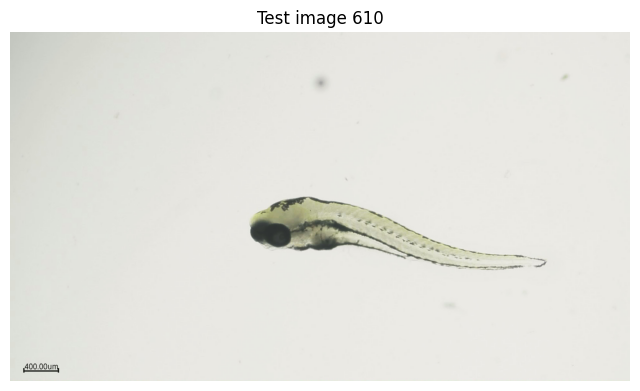


IMAGE 570
Path: /content/drive/MyDrive/ZEBRA_SCAN/train_images/train_images/570.png

Errors:


,phenotype,true,predicted,probability,threshold,error_type,error_confidence
0,yolk_edema,1,0,0.0152,0.6,FALSE NEGATIVE,0.9848


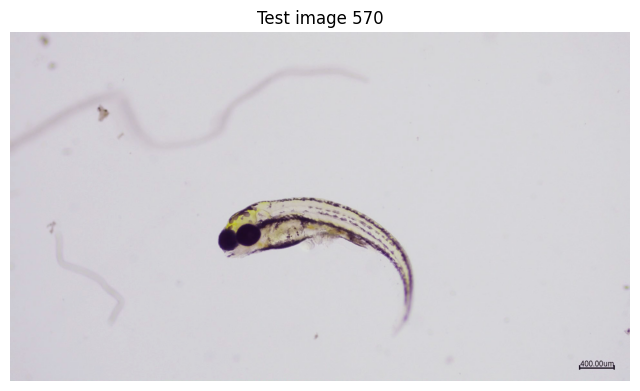


IMAGE 770
Path: /content/drive/MyDrive/ZEBRA_SCAN/train_images/train_images/770.png

Errors:


,phenotype,true,predicted,probability,threshold,error_type,error_confidence
0,dead,1,0,0.2109,0.85,FALSE NEGATIVE,0.7891
1,unhatched_embryo,0,1,0.9833,0.24,FALSE POSITIVE,0.9833


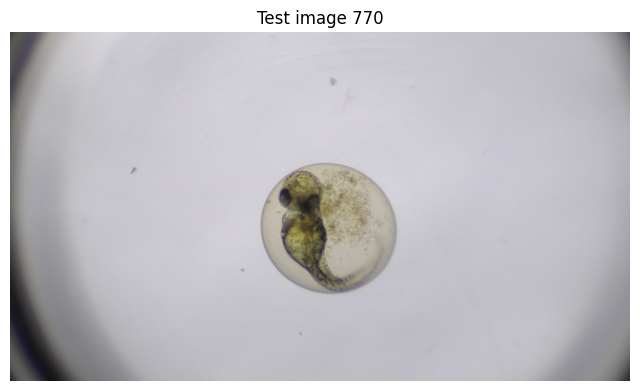


IMAGE 539
Path: /content/drive/MyDrive/ZEBRA_SCAN/train_images/train_images/539.png

Errors:


,phenotype,true,predicted,probability,threshold,error_type,error_confidence
0,head_hemorrhage,0,1,0.9721,0.9,FALSE POSITIVE,0.9721


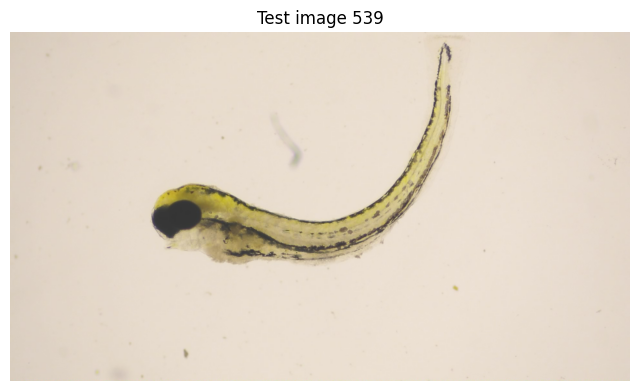


IMAGE 1262
Path: /content/drive/MyDrive/ZEBRA_SCAN/train_images/train_images/1262.png

Errors:


,phenotype,true,predicted,probability,threshold,error_type,error_confidence
0,head_hemorrhage,1,0,0.0522,0.9,FALSE NEGATIVE,0.9478


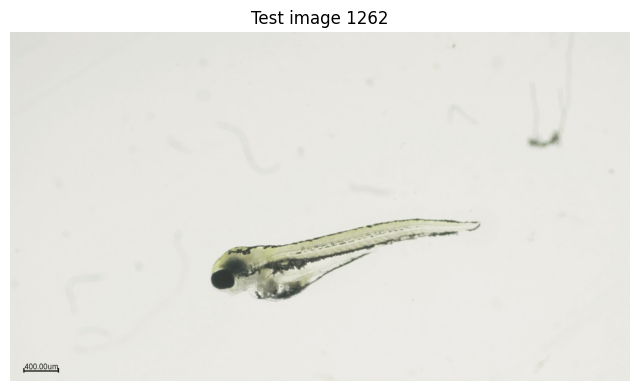

In [68]:
# ============================================================
# VISUAL FAILURE ANALYSIS — INSPECT ACTUAL TEST IMAGES
# ============================================================

import os
import matplotlib.pyplot as plt
from PIL import Image

# Strong, informative failures selected from the locked test results
failure_ids = [610, 570, 770, 539, 1262]

print("Selected failure cases:")
print("  610  -> multiple simultaneous errors")
print("  570  -> confident yolk_edema false negative")
print("  770  -> confident unhatched_embryo false positive")
print("  539  -> confident head_hemorrhage false positive")
print("  1262 -> confident head_hemorrhage false negative")

# Find image path from the same directories already defined in the notebook
def find_image(image_id):
    filename = f"{int(image_id)}.png"

    candidates = [
        os.path.join(TRAIN_IMG_DIR, filename),
        os.path.join(TEST_IMG_DIR, filename),
    ]

    for path in candidates:
        if os.path.exists(path):
            return path

    return None


for image_id in failure_ids:

    row_errors = errors_df[errors_df["image_id"] == image_id].copy()

    path = find_image(image_id)

    print("\n" + "=" * 80)
    print(f"IMAGE {image_id}")
    print("=" * 80)

    if path is None:
        print("IMAGE NOT FOUND")
        continue

    print("Path:", path)

    print("\nErrors:")
    display(
        row_errors[
            [
                "phenotype",
                "true",
                "predicted",
                "probability",
                "threshold",
                "error_type",
                "error_confidence"
            ]
        ].reset_index(drop=True)
    )

    img = Image.open(path)

    plt.figure(figsize=(8, 6))
    plt.imshow(img, cmap="gray")
    plt.title(f"Test image {image_id}")
    plt.axis("off")
    plt.show()

In [3]:
import os
import shutil

mountpoint = "/content/drive"

if os.path.exists(mountpoint):
    shutil.rmtree(mountpoint)

from google.colab import drive
drive.mount(mountpoint)

Mounted at /content/drive


*GRAD CAM


Grad-CAM device: cpu
Loaded fold 0
Loaded fold 1
Loaded fold 2
Loaded fold 3
Loaded fold 4

All 5 A1 models loaded successfully.

IMAGE 610
Target phenotype: bent_spine
Path: /content/drive/MyDrive/ZEBRA_SCAN/test_images/test_images/610.png
Ensemble probability for bent_spine: 0.9927


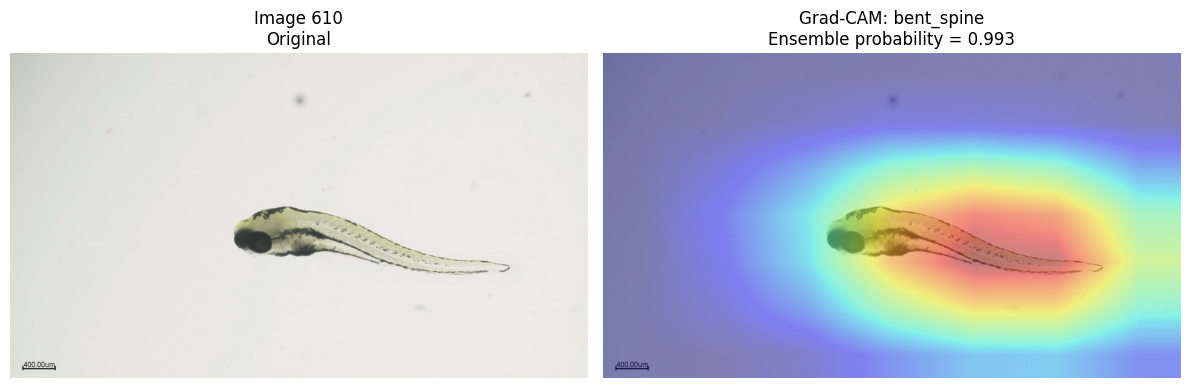

Saved: /content/drive/MyDrive/ZEBRA_SCAN/outputs/gradcam_failure_analysis/610_bent_spine_gradcam.png

IMAGE 570
Target phenotype: yolk_edema
Path: /content/drive/MyDrive/ZEBRA_SCAN/train_images/train_images/570.png
Ensemble probability for yolk_edema: 0.0152


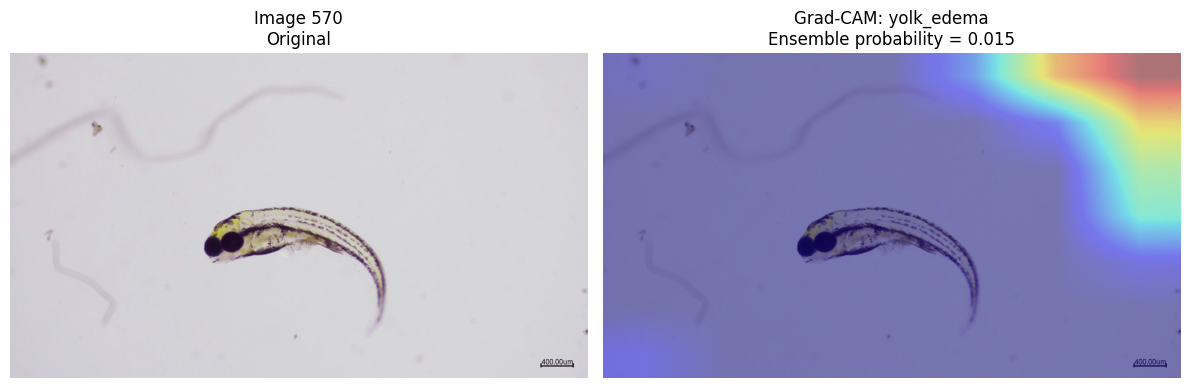

Saved: /content/drive/MyDrive/ZEBRA_SCAN/outputs/gradcam_failure_analysis/570_yolk_edema_gradcam.png

IMAGE 770
Target phenotype: unhatched_embryo
Path: /content/drive/MyDrive/ZEBRA_SCAN/train_images/train_images/770.png
Ensemble probability for unhatched_embryo: 0.9833


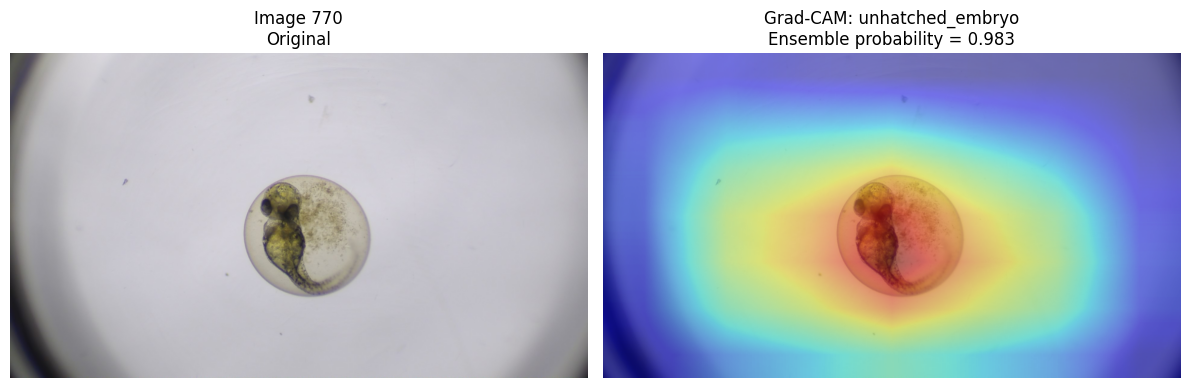

Saved: /content/drive/MyDrive/ZEBRA_SCAN/outputs/gradcam_failure_analysis/770_unhatched_embryo_gradcam.png

IMAGE 539
Target phenotype: head_hemorrhage
Path: /content/drive/MyDrive/ZEBRA_SCAN/train_images/train_images/539.png
Ensemble probability for head_hemorrhage: 0.9721


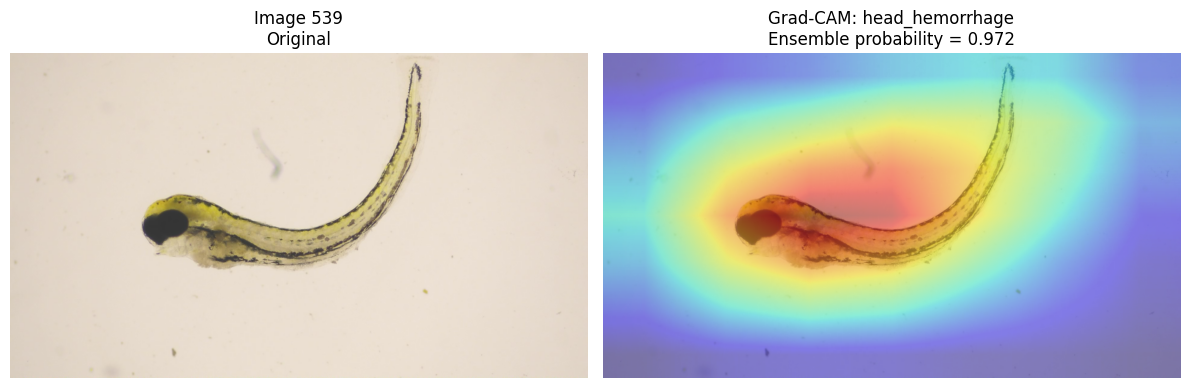

Saved: /content/drive/MyDrive/ZEBRA_SCAN/outputs/gradcam_failure_analysis/539_head_hemorrhage_gradcam.png

IMAGE 1262
Target phenotype: head_hemorrhage
Path: /content/drive/MyDrive/ZEBRA_SCAN/train_images/train_images/1262.png
Ensemble probability for head_hemorrhage: 0.0522


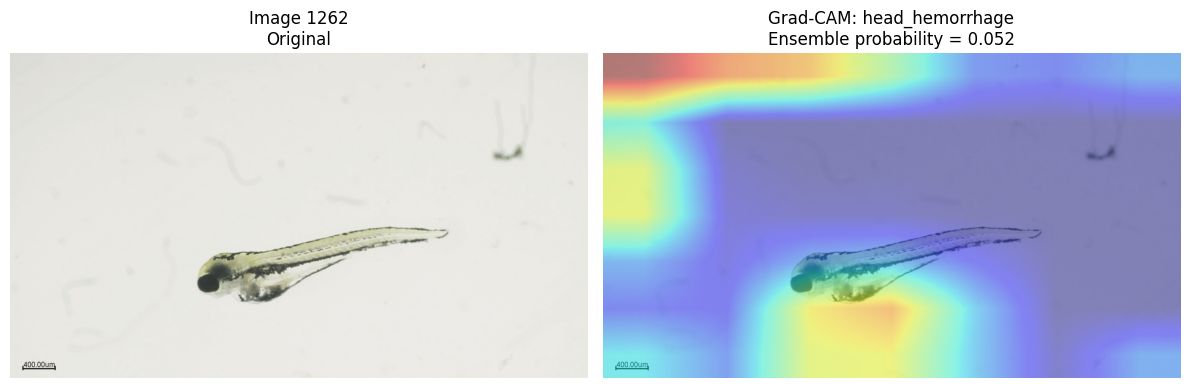

Saved: /content/drive/MyDrive/ZEBRA_SCAN/outputs/gradcam_failure_analysis/1262_head_hemorrhage_gradcam.png

Grad-CAM analysis complete.


In [4]:
# ============================================================
# ZEBRA-SCAN — A1 Ensemble Grad-CAM
# CPU SAFE — NO RETRAINING
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/ZEBRA_SCAN"
TRAIN_IMG_DIR = f"{BASE_DIR}/train_images/train_images"
TEST_IMG_DIR = f"{BASE_DIR}/test_images/test_images"

CNN_DIR = f"{BASE_DIR}/outputs/cnn_independent_split"
GRADCAM_DIR = f"{BASE_DIR}/outputs/gradcam_failure_analysis"

os.makedirs(GRADCAM_DIR, exist_ok=True)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

PHENOTYPES = [
    "bent_spine",
    "jaw_malformation",
    "swim_bladder_absence",
    "yolk_edema",
    "pericardial_edema",
    "dead",
    "head_hemorrhage",
    "unhatched_embryo"
]

# Selected failure cases
FAILURE_CASES = {
    610: "bent_spine",
    570: "yolk_edema",
    770: "unhatched_embryo",
    539: "head_hemorrhage",
    1262: "head_hemorrhage"
}

# ------------------------------------------------------------
# CPU
# ------------------------------------------------------------

DEVICE = torch.device("cpu")
print("Grad-CAM device:", DEVICE)

# ------------------------------------------------------------
# Same validation preprocessing used by A1
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------------------------------------------------------
# Recreate the exact A1 architecture
# ------------------------------------------------------------

class ResNet18MultiLabel(nn.Module):

    def __init__(self, n_classes=8):
        super().__init__()

        self.backbone = models.resnet18(weights=None)

        in_features = self.backbone.fc.in_features

        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.30),
            nn.Linear(in_features, n_classes)
        )

    def forward(self, x):
        return self.backbone(x)


# ------------------------------------------------------------
# Load all five frozen A1 models
# ------------------------------------------------------------

models_list = []

for fold in range(5):

    ckpt_path = os.path.join(
        CNN_DIR,
        f"A1_resnet18_fold{fold}.pt"
    )

    model = ResNet18MultiLabel(n_classes=8)

    checkpoint = torch.load(
        ckpt_path,
        map_location=DEVICE
    )

    # Handle either a raw state_dict or a checkpoint dictionary
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    elif isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint

    # Remove DataParallel prefix if present
    state_dict = {
        k.replace("module.", "", 1) if k.startswith("module.") else k: v
        for k, v in state_dict.items()
    }

    model.load_state_dict(state_dict, strict=True)
    model.to(DEVICE)
    model.eval()

    models_list.append(model)

    print(f"Loaded fold {fold}")

print("\nAll 5 A1 models loaded successfully.")


# ------------------------------------------------------------
# Locate image
# ------------------------------------------------------------

def find_image(image_id):

    filename = f"{int(image_id)}.png"

    candidates = [
        os.path.join(TRAIN_IMG_DIR, filename),
        os.path.join(TEST_IMG_DIR, filename)
    ]

    for path in candidates:
        if os.path.exists(path):
            return path

    raise FileNotFoundError(
        f"Could not find image {filename}"
    )


# ------------------------------------------------------------
# Grad-CAM for one model
# ------------------------------------------------------------

def gradcam_single_model(model, image_tensor, target_index):

    activations = []
    gradients = []

    target_layer = model.backbone.layer4[-1].conv2

    def forward_hook(module, inp, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    handle_forward = target_layer.register_forward_hook(forward_hook)
    handle_backward = target_layer.register_full_backward_hook(
        backward_hook
    )

    model.zero_grad(set_to_none=True)

    output = model(image_tensor)

    target_score = output[0, target_index]

    target_score.backward()

    # Remove hooks
    handle_forward.remove()
    handle_backward.remove()

    activation = activations[0]
    gradient = gradients[0]

    # Global-average-pool gradients
    weights = gradient.mean(
        dim=(2, 3),
        keepdim=True
    )

    cam = (weights * activation).sum(dim=1)

    cam = torch.relu(cam)

    cam = cam[0].detach().cpu().numpy()

    # Normalize
    cam -= cam.min()

    if cam.max() > 0:
        cam /= cam.max()

    return cam, output[0].detach().cpu().numpy()


# ------------------------------------------------------------
# Ensemble Grad-CAM
# ------------------------------------------------------------

def ensemble_gradcam(image_path, target_index):

    original = Image.open(image_path).convert("RGB")

    image_tensor = transform(original).unsqueeze(0).to(DEVICE)

    cams = []
    probabilities = []

    for model in models_list:

        cam, logits = gradcam_single_model(
            model,
            image_tensor,
            target_index
        )

        cams.append(cam)

        probs = torch.sigmoid(
            torch.tensor(logits)
        ).numpy()

        probabilities.append(probs)

    # Average predictions across five folds
    probabilities = np.mean(
        probabilities,
        axis=0
    )

    # Resize each CAM to original image size
    resized_cams = []

    for cam in cams:

        cam_img = Image.fromarray(
            np.uint8(cam * 255)
        )

        cam_img = cam_img.resize(
            original.size,
            Image.Resampling.BILINEAR
        )

        cam_resized = (
            np.asarray(cam_img)
            .astype(np.float32) / 255.0
        )

        resized_cams.append(cam_resized)

    # Average five fold CAMs
    ensemble_cam = np.mean(
        resized_cams,
        axis=0
    )

    ensemble_cam -= ensemble_cam.min()

    if ensemble_cam.max() > 0:
        ensemble_cam /= ensemble_cam.max()

    return original, ensemble_cam, probabilities


# ------------------------------------------------------------
# Generate Grad-CAMs
# ------------------------------------------------------------

for image_id, phenotype in FAILURE_CASES.items():

    target_index = PHENOTYPES.index(phenotype)

    image_path = find_image(image_id)

    print("\n" + "=" * 70)
    print(f"IMAGE {image_id}")
    print(f"Target phenotype: {phenotype}")
    print(f"Path: {image_path}")

    original, cam, probabilities = ensemble_gradcam(
        image_path,
        target_index
    )

    probability = probabilities[target_index]

    print(
        f"Ensemble probability for {phenotype}: "
        f"{probability:.4f}"
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 5)
    )

    # Original
    axes[0].imshow(original)
    axes[0].set_title(
        f"Image {image_id}\nOriginal"
    )
    axes[0].axis("off")

    # Grad-CAM
    axes[1].imshow(original)

    axes[1].imshow(
        cam,
        cmap="jet",
        alpha=0.45
    )

    axes[1].set_title(
        f"Grad-CAM: {phenotype}\n"
        f"Ensemble probability = {probability:.3f}"
    )

    axes[1].axis("off")

    plt.tight_layout()

    output_path = os.path.join(
        GRADCAM_DIR,
        f"{image_id}_{phenotype}_gradcam.png"
    )

    plt.savefig(
        output_path,
        dpi=180,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print(f"Saved: {output_path}")

print("\nGrad-CAM analysis complete.")

*ZEBRA_APP


In [5]:
import os

BASE_DIR = "/content/drive/MyDrive/ZEBRA_SCAN"

APP_DIR = f"{BASE_DIR}/deployment/ZEBRA_SCAN_APP"

os.makedirs(APP_DIR, exist_ok=True)

print("Created:")
print(APP_DIR)

Created:
/content/drive/MyDrive/ZEBRA_SCAN/deployment/ZEBRA_SCAN_APP


In [6]:
import os
import shutil

CNN_DIR = f"{BASE_DIR}/outputs/cnn_independent_split"
HYBRID_DIR = f"{BASE_DIR}/outputs/hybrid_independent_split"

MODEL_DIR = f"{APP_DIR}/models"
CONFIG_DIR = f"{APP_DIR}/config"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CONFIG_DIR, exist_ok=True)

# Copy the five frozen A1 models
for fold in range(5):

    src = f"{CNN_DIR}/A1_resnet18_fold{fold}.pt"
    dst = f"{MODEL_DIR}/A1_resnet18_fold{fold}.pt"

    shutil.copy2(src, dst)

    print("Copied:", os.path.basename(src))

# Copy frozen thresholds
src = f"{HYBRID_DIR}/A1_optimized_thresholds.npy"
dst = f"{CONFIG_DIR}/A1_optimized_thresholds.npy"

shutil.copy2(src, dst)

print("\nThresholds copied.")

Copied: A1_resnet18_fold0.pt
Copied: A1_resnet18_fold1.pt
Copied: A1_resnet18_fold2.pt
Copied: A1_resnet18_fold3.pt
Copied: A1_resnet18_fold4.pt

Thresholds copied.


In [7]:
for root, dirs, files in os.walk(APP_DIR):
    level = root.replace(APP_DIR, "").count(os.sep)
    indent = "  " * level
    print(indent + os.path.basename(root) + "/")

    for file in files:
        print(indent + "  " + file)

ZEBRA_SCAN_APP/
  models/
    A1_resnet18_fold0.pt
    A1_resnet18_fold1.pt
    A1_resnet18_fold2.pt
    A1_resnet18_fold3.pt
    A1_resnet18_fold4.pt
  config/
    A1_optimized_thresholds.npy
